In [1]:
"""IMPORTAR"""

import pandas as pd
import os
from scipy.interpolate import PchipInterpolator
import numpy as np
import copy
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import matplotlib.pyplot as plt

import importlib
import funciones
importlib.reload(funciones)
print()
from funciones import J_univariante, generar_uniforme_centrada, interpolador, remove_consecutive_duplicates

from music21 import *
environment.set('musescoreDirectPNGPath', r"C:\Program Files\MuseScore 4\bin\MuseScore4.exe")


In [2]:
def process_notes(m21_data, start_measure=1):
    notes = []
    
    for part in m21_data.parts:
        for note in part.flatten().notes:
            try:
                measure = note.measureNumber + (start_measure - 1)
                start = float(note.offset)
                duration = float(note.quarterLength)
                
                if note.isChord:
                    for chord_note in note.pitches:
                        pitch = float(chord_note.ps)
                        notes.append([measure, start, start + duration, duration, pitch])
                else:
                    pitch = float(note.pitch.ps)
                    notes.append([measure, start, start + duration, duration, pitch])
            except:
                try:
                    start = float(note.offset)
                except:
                    try:
                        numer = note.offset.numerator
                        denom = note.offset.denominator
                        start = float(numer / denom)
                    except:
                        start = float(note.offset)
                
                try:
                    duration = float(note.quarterLength)
                except:
                    try:
                        numer = note.quarterLength.numerator
                        denom = note.quarterLength.denominator
                        duration = float(numer / denom)
                    except:
                        duration = float(note.quarterLength)
                
                for chord_note in note.pitches:
                    pitch = float(chord_note.ps)
                    notes.append([measure, start, start + duration, duration, pitch])
    
    all_notes = np.array(notes, dtype=object)
    n_measures = int(np.max(all_notes[:, 0]))
    
    timesig = []
    lquarters = []
    for i in range(n_measures + 1):
        try:
            ts = m21_data.parts[0].measure(i).timeSignature
            timesig.append([i, ts.ratioString])
            nquarters = ts.numerator / ts.denominator * 4
            lquarters.append([i, nquarters])
        except:
            pass
    
    measures_piece = []
    if len(timesig) > 1:
        for n_ts in range(1, len(timesig)):
            last_m = timesig[n_ts][0]
            first_m = timesig[n_ts - 1][0]
            ix = np.where((all_notes[:, 0] >= first_m) & (all_notes[:, 0] <= last_m))
            m_ts = [timesig[n_ts - 1][1]] * len(ix[0])
            measures_piece.append(np.column_stack((all_notes[ix], m_ts)))
        
        last_m = n_measures
        first_m = timesig[-1][0]
        ix = np.where((all_notes[:, 0] >= first_m) & (all_notes[:, 0] <= last_m))
        m_ts = [timesig[-1][1]] * len(ix[0])
        measures_piece.append(np.column_stack((all_notes[ix], m_ts)))
    else:
        m_ts = [timesig[0][1]] * len(all_notes)
        measures_piece.append(np.column_stack((all_notes, m_ts)))
    
    out_measures = np.vstack(measures_piece)
    return out_measures[np.lexsort((out_measures[:, 1].astype(float), out_measures[:, 0].astype(float)))]

def midi_to_note(midi_number):
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    octave = midi_number // 12 - 1
    note_index = midi_number % 12
    note = note_names[note_index]
    return f"{note}{octave}"

def midi_to_note_list(array):
    notas = []
    for x in array:
        # notas.append(columna[i])
        notas.append(midi_to_note(int(x)))
    return notas


def extract_midi_sequence(notes_matrix):
    unique_starts = np.unique(notes_matrix[:, 1].astype(float))
    midi_sequence = []
    
    for start in unique_starts:
        notes_at_start = notes_matrix[notes_matrix[:, 1].astype(float) == start]
        highest_pitch = np.max(notes_at_start[:, 4].astype(float))
        midi_sequence.append(highest_pitch)
    
    return midi_sequence

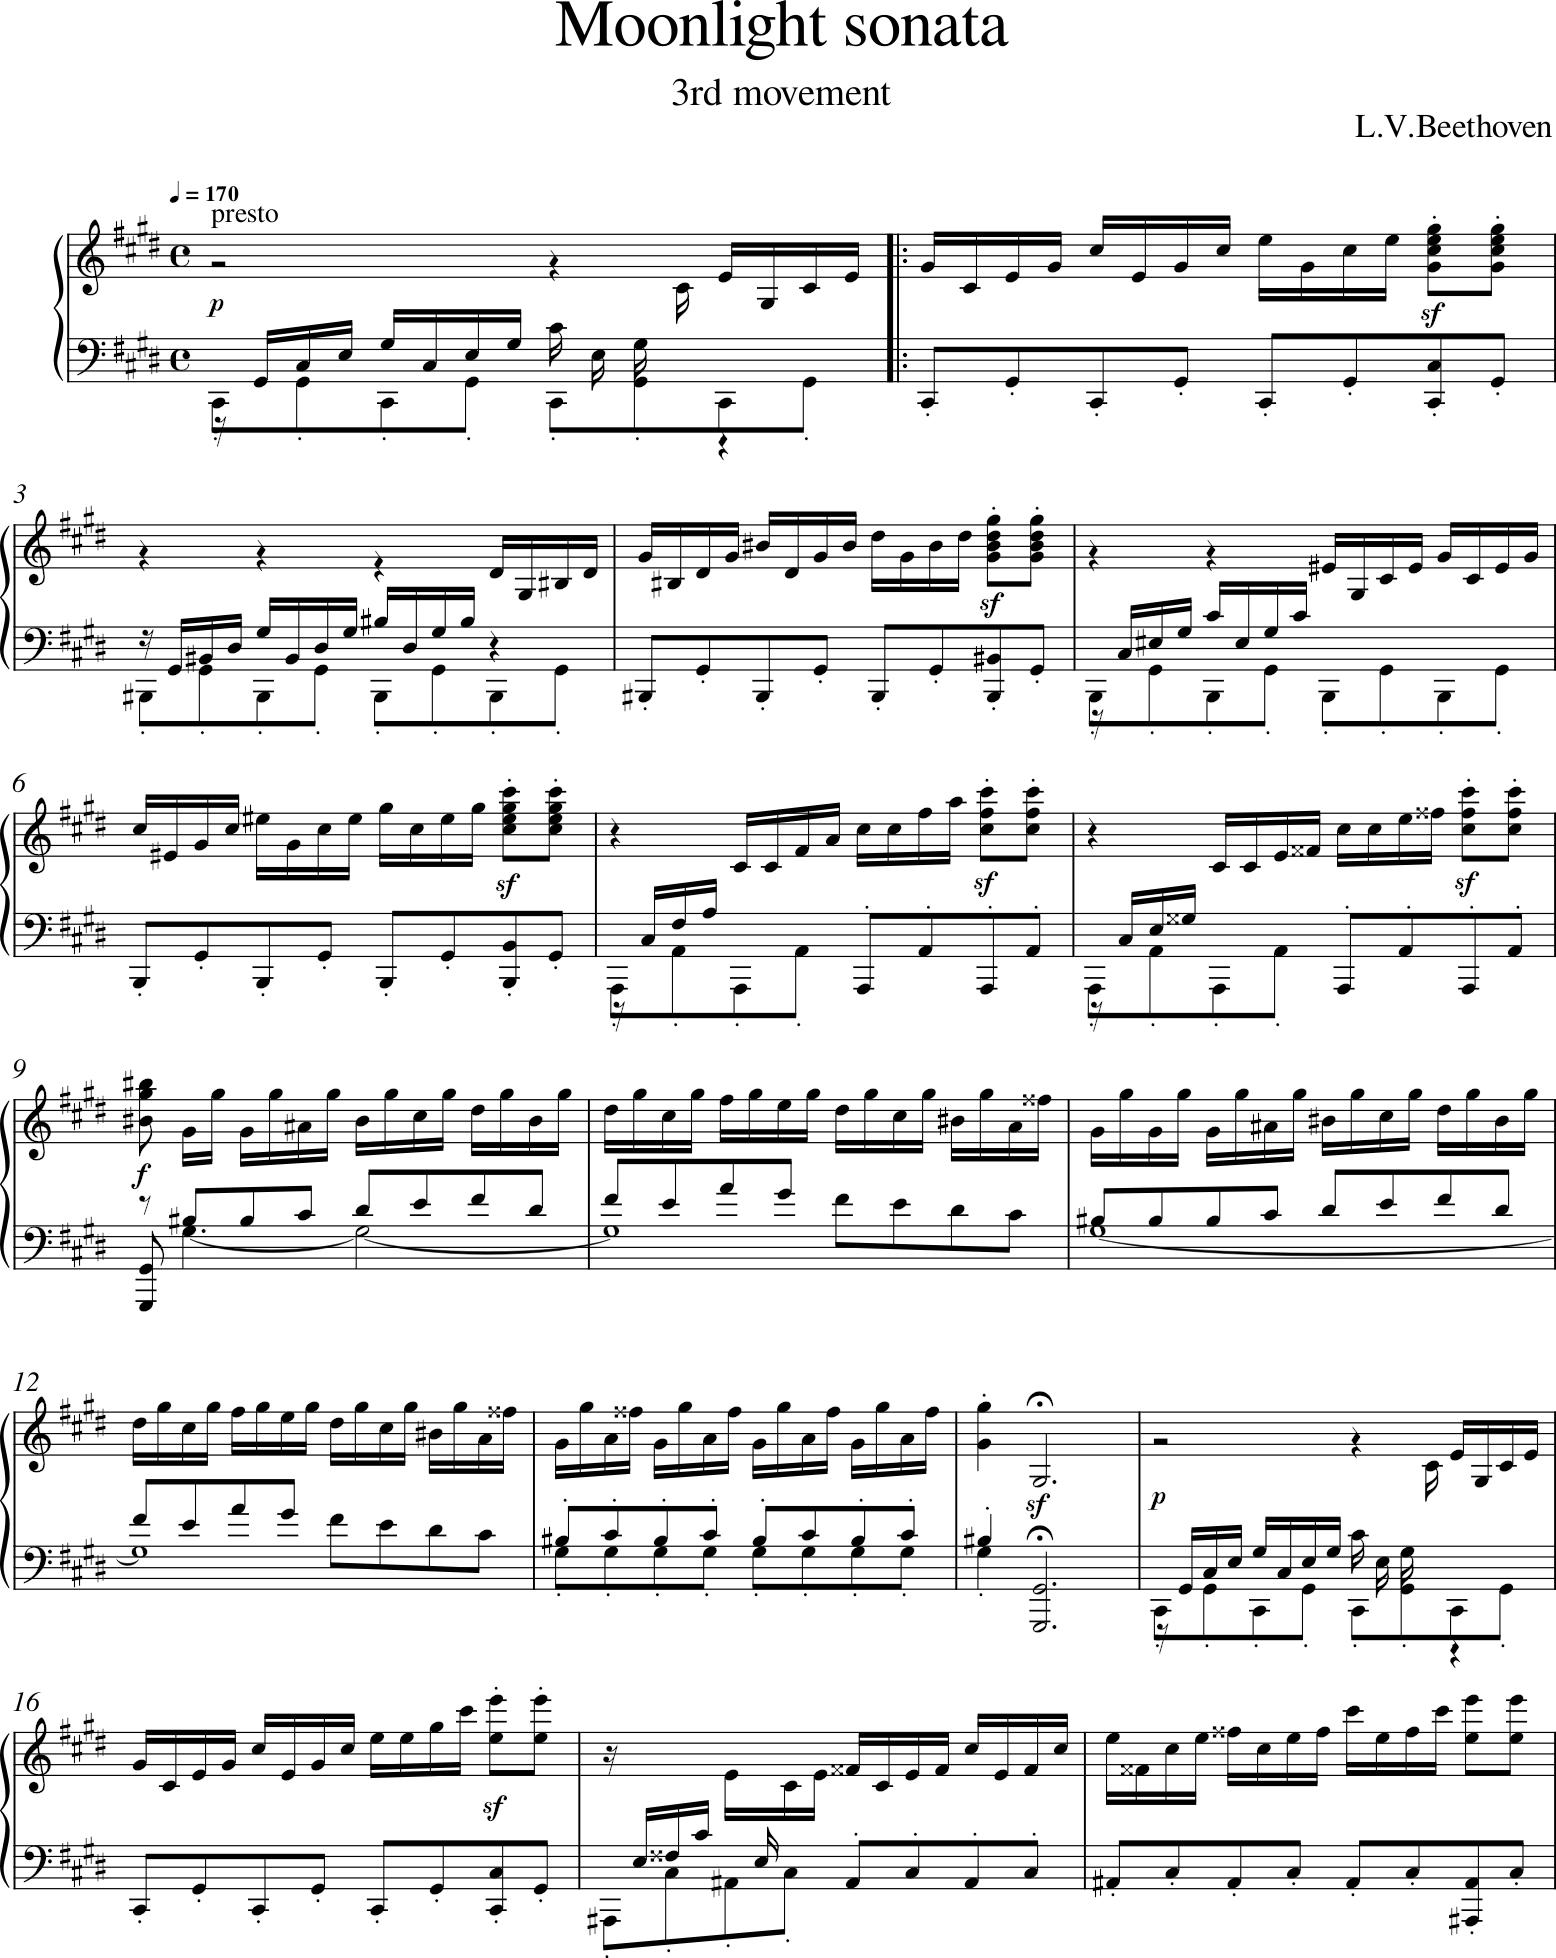

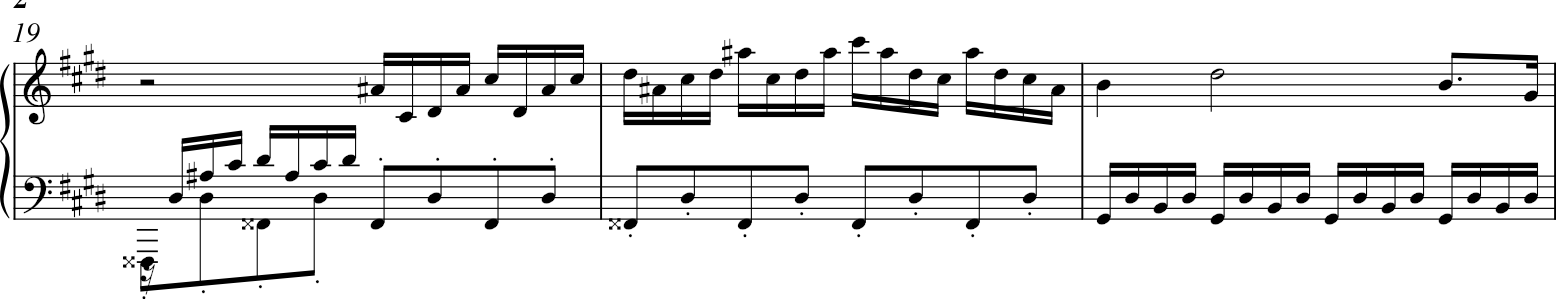

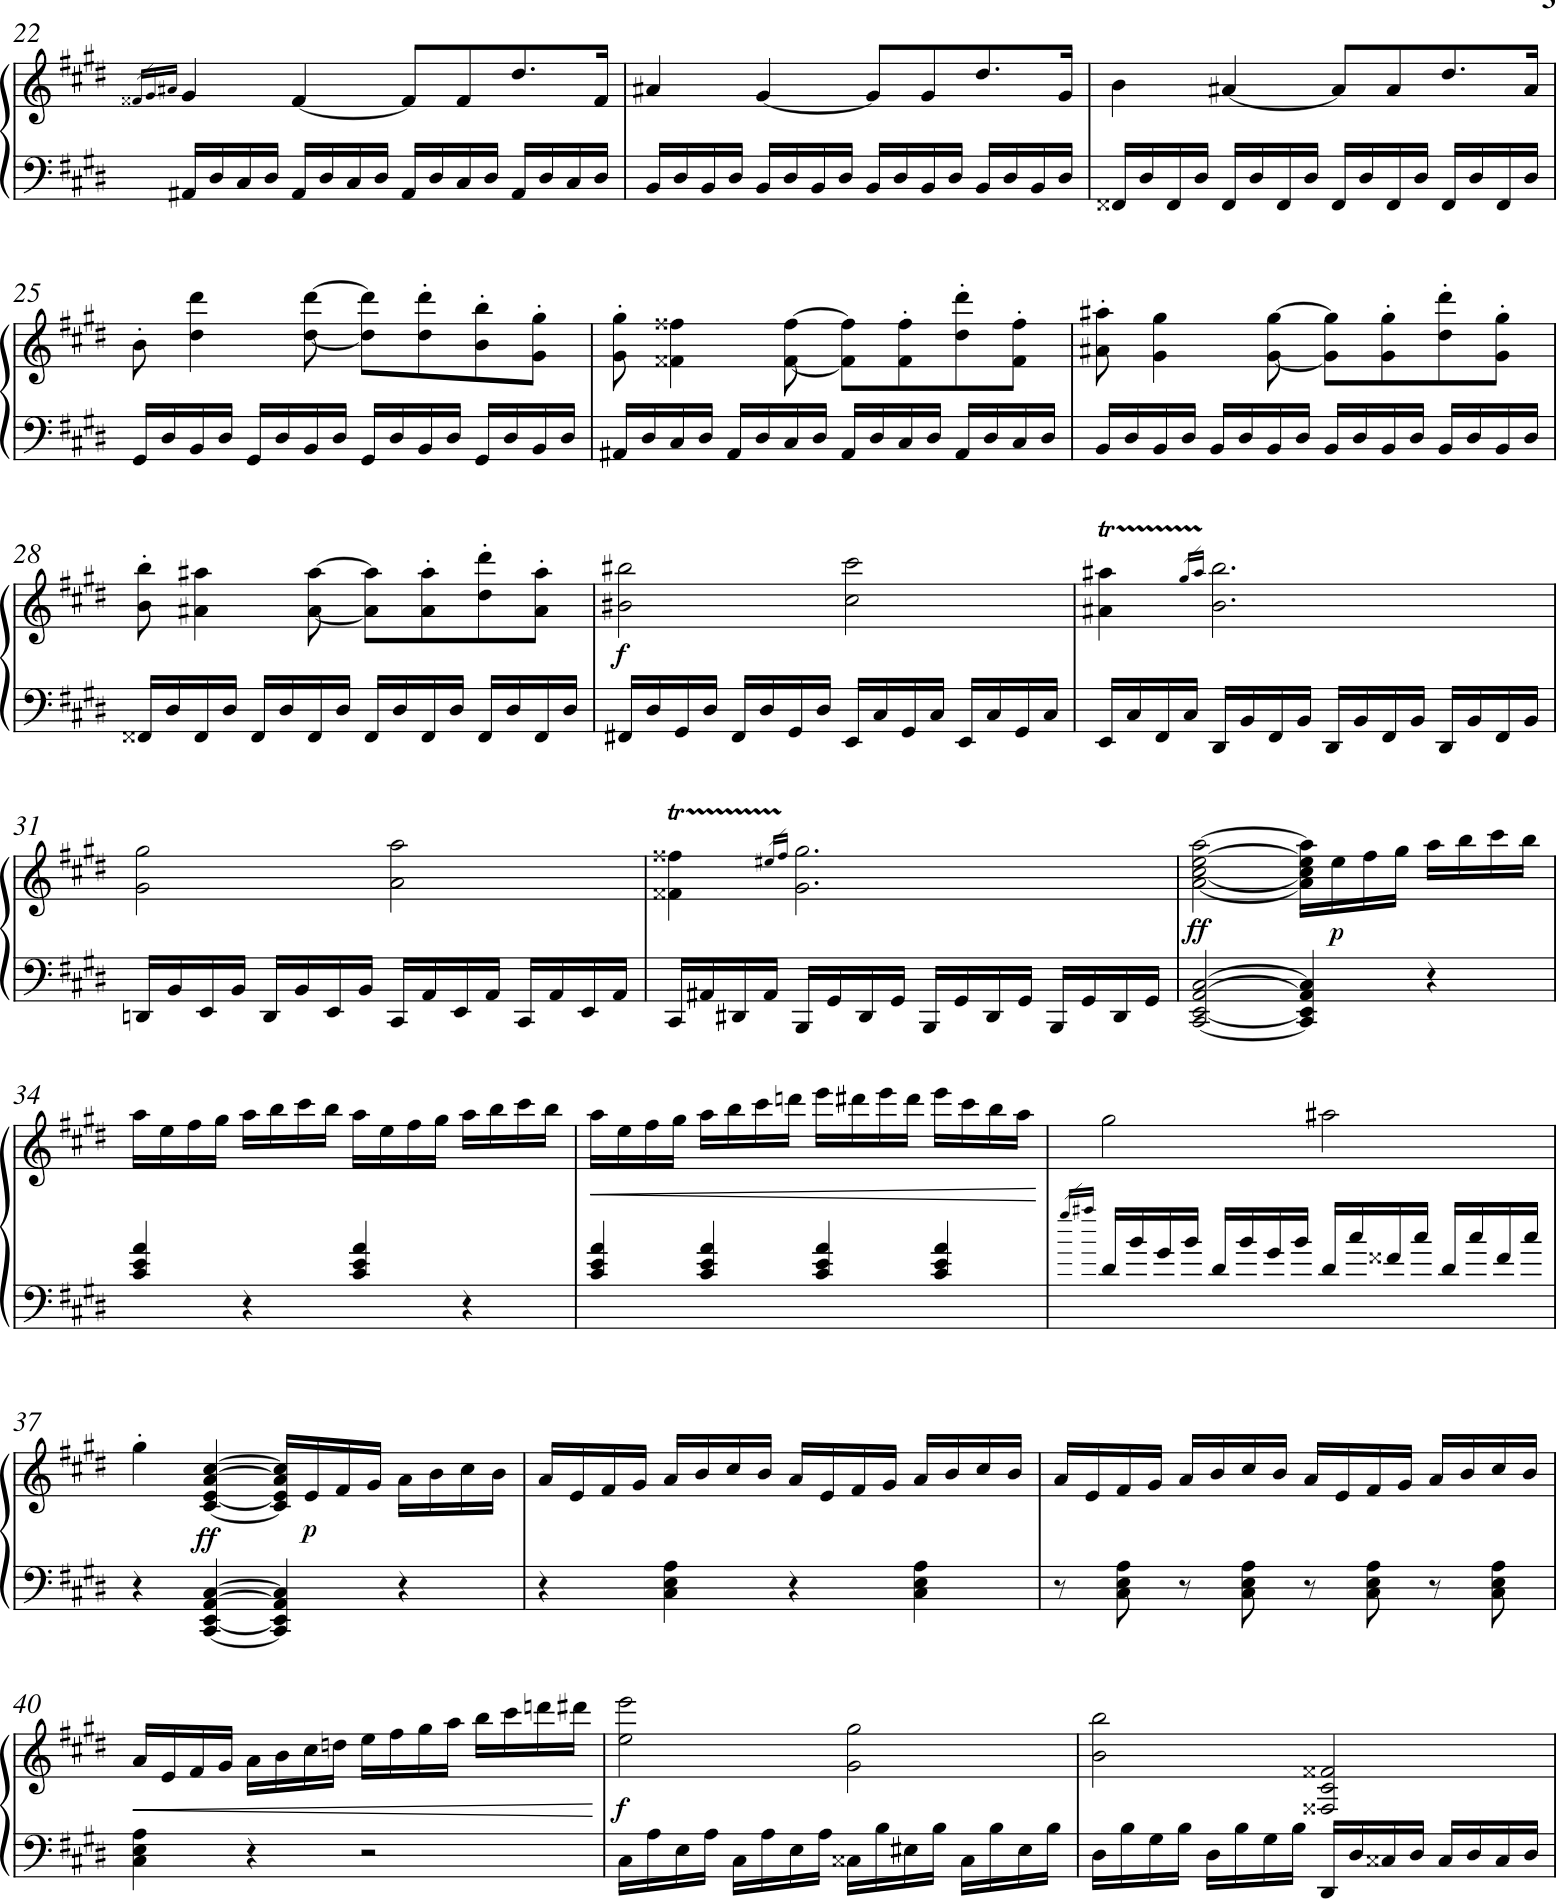

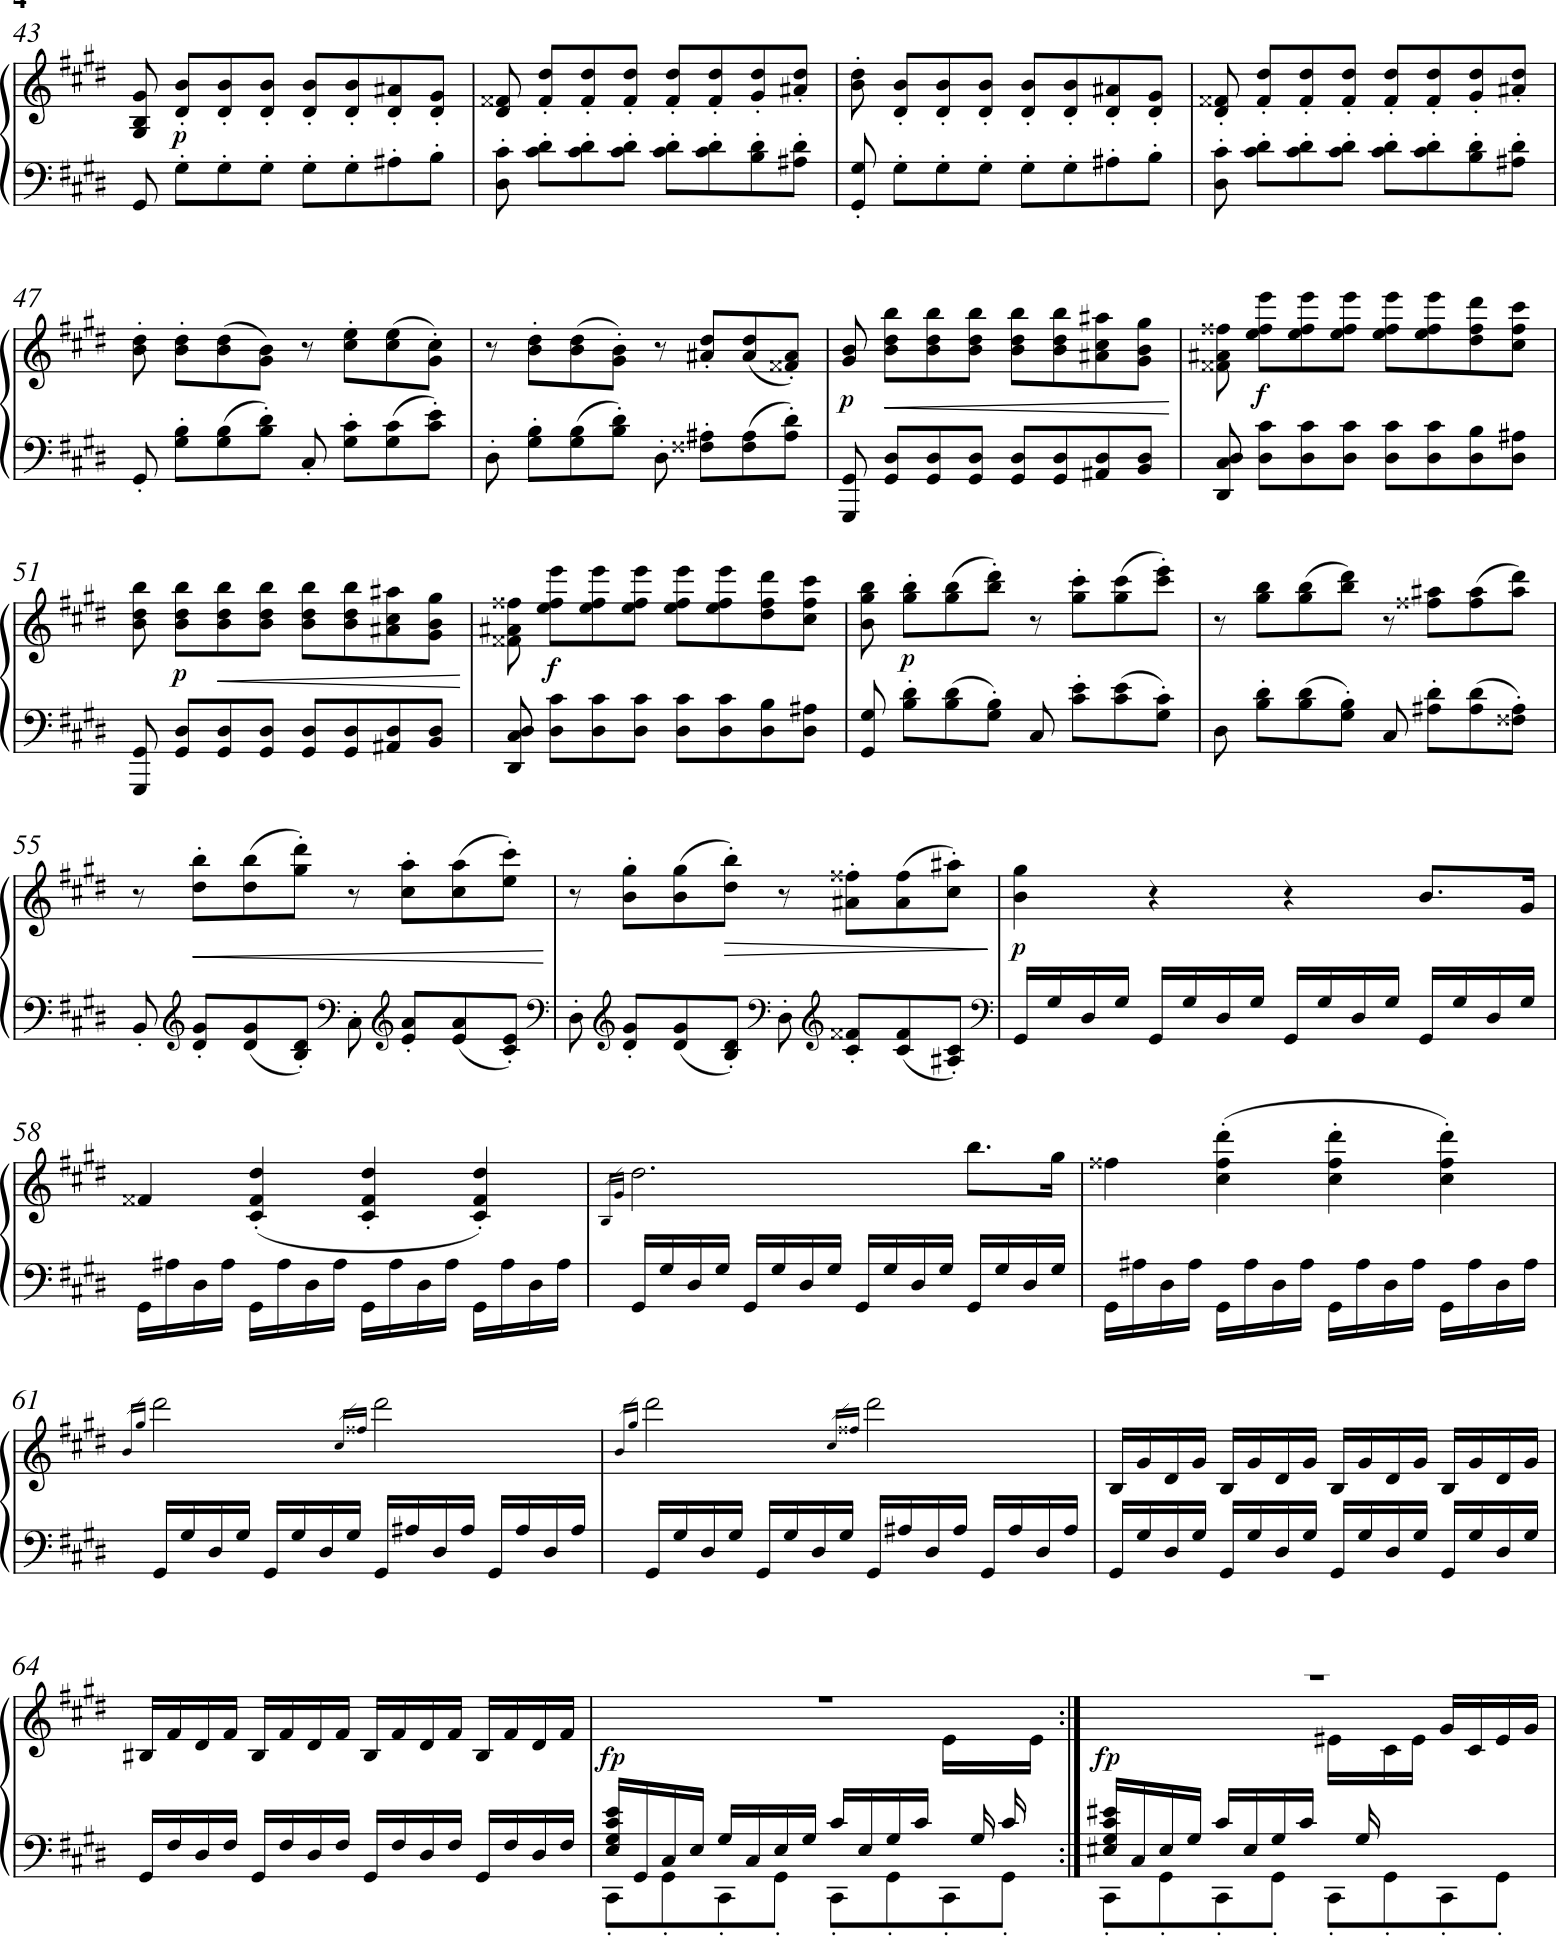

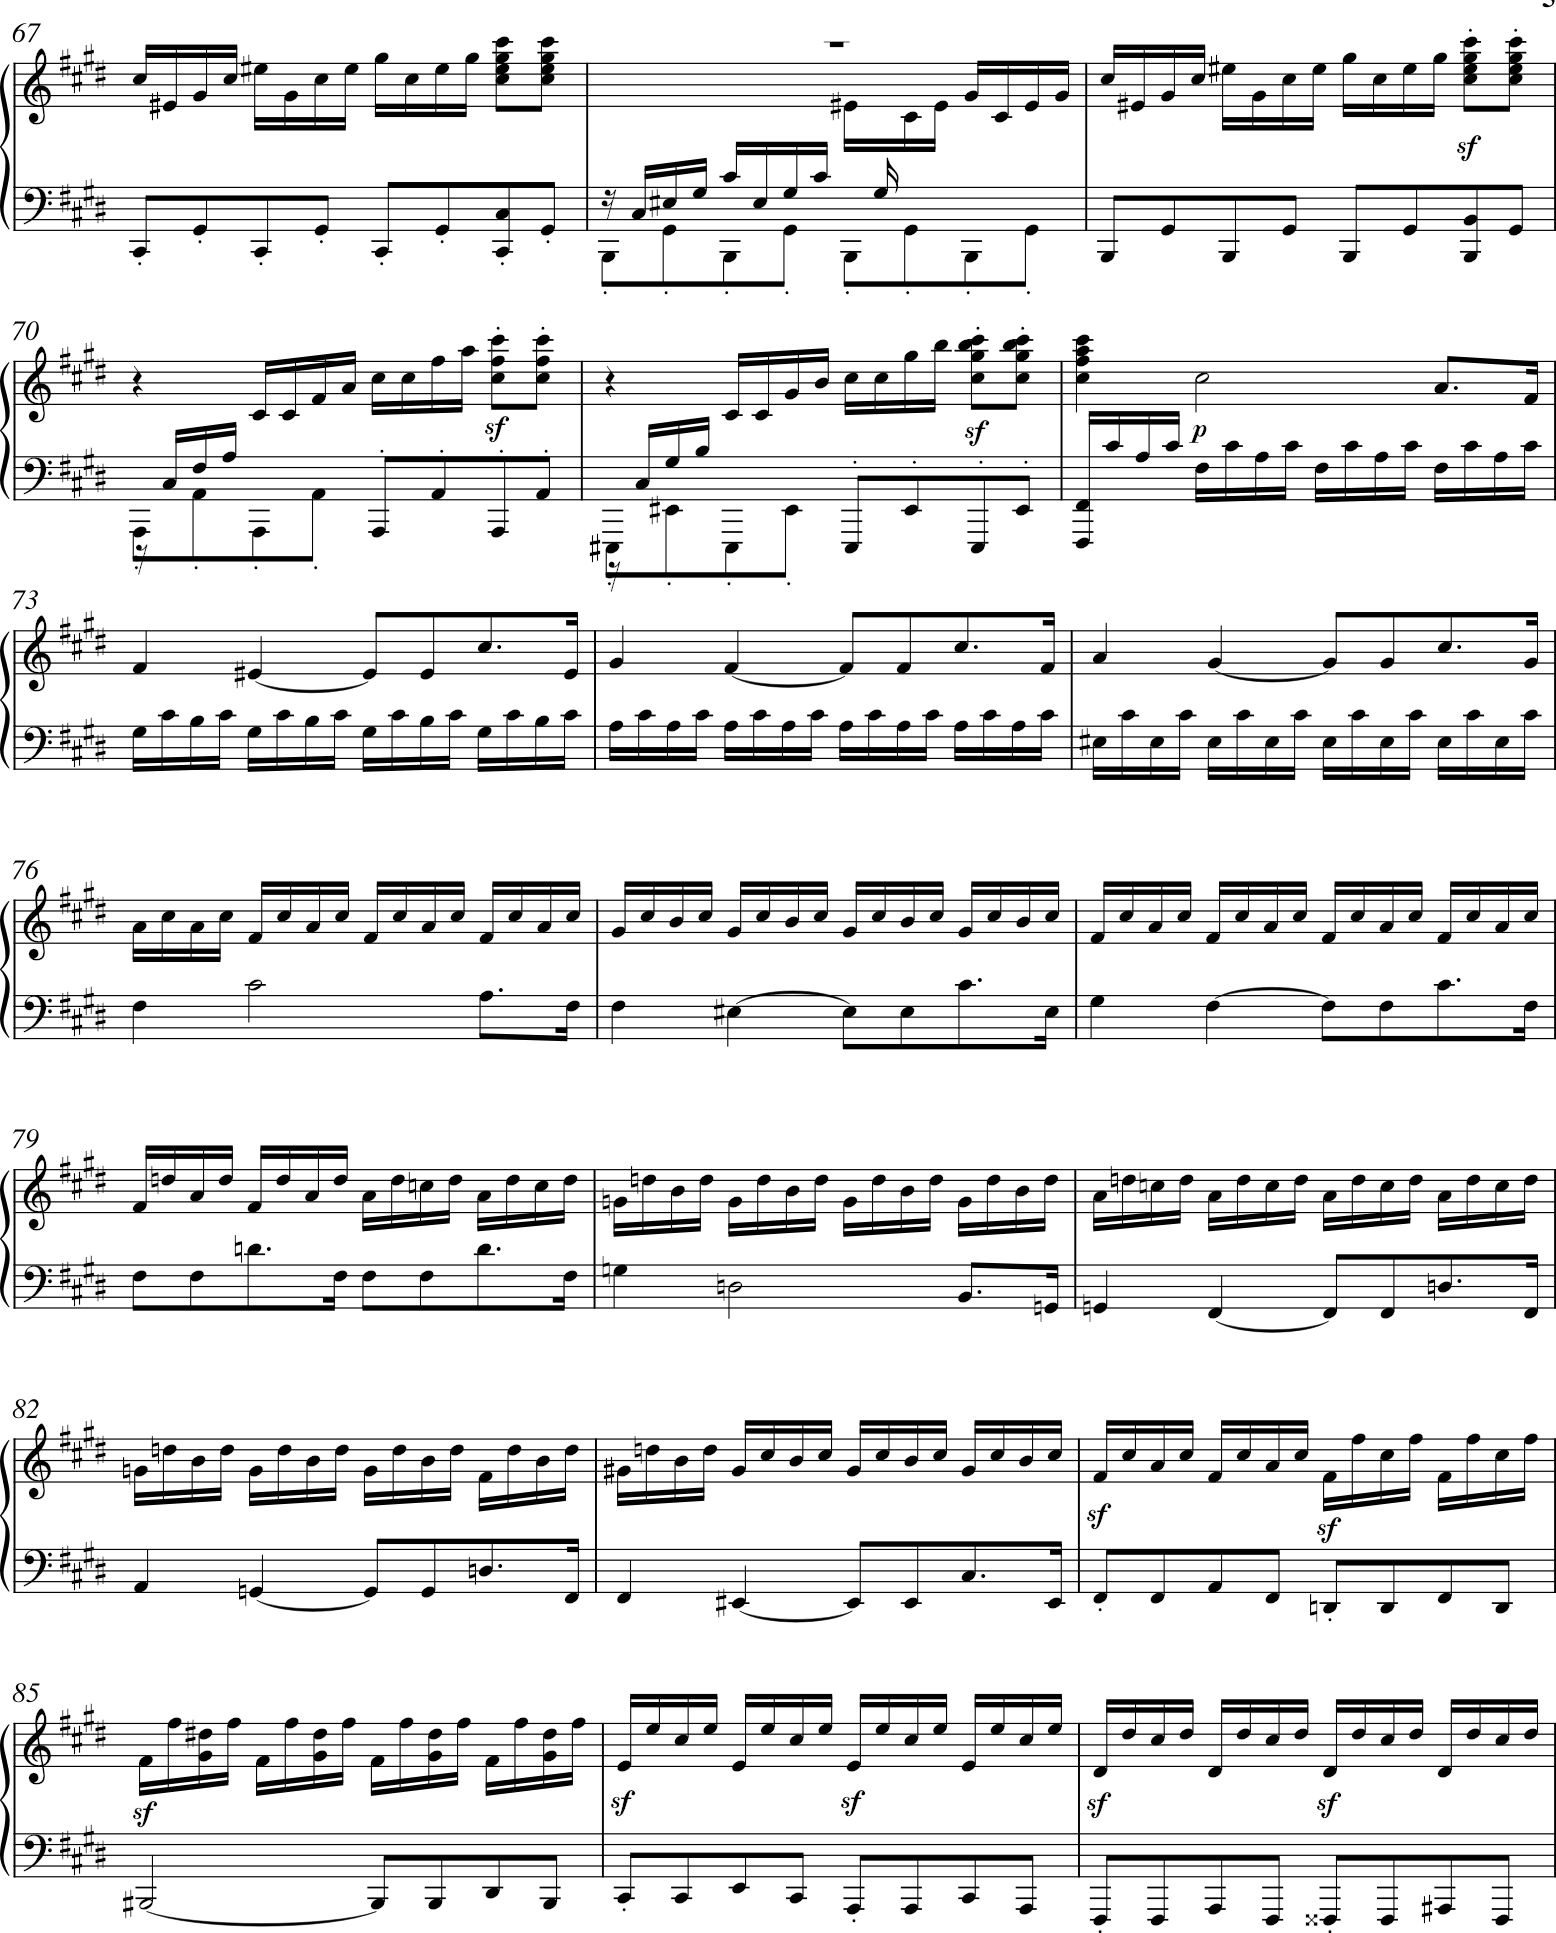

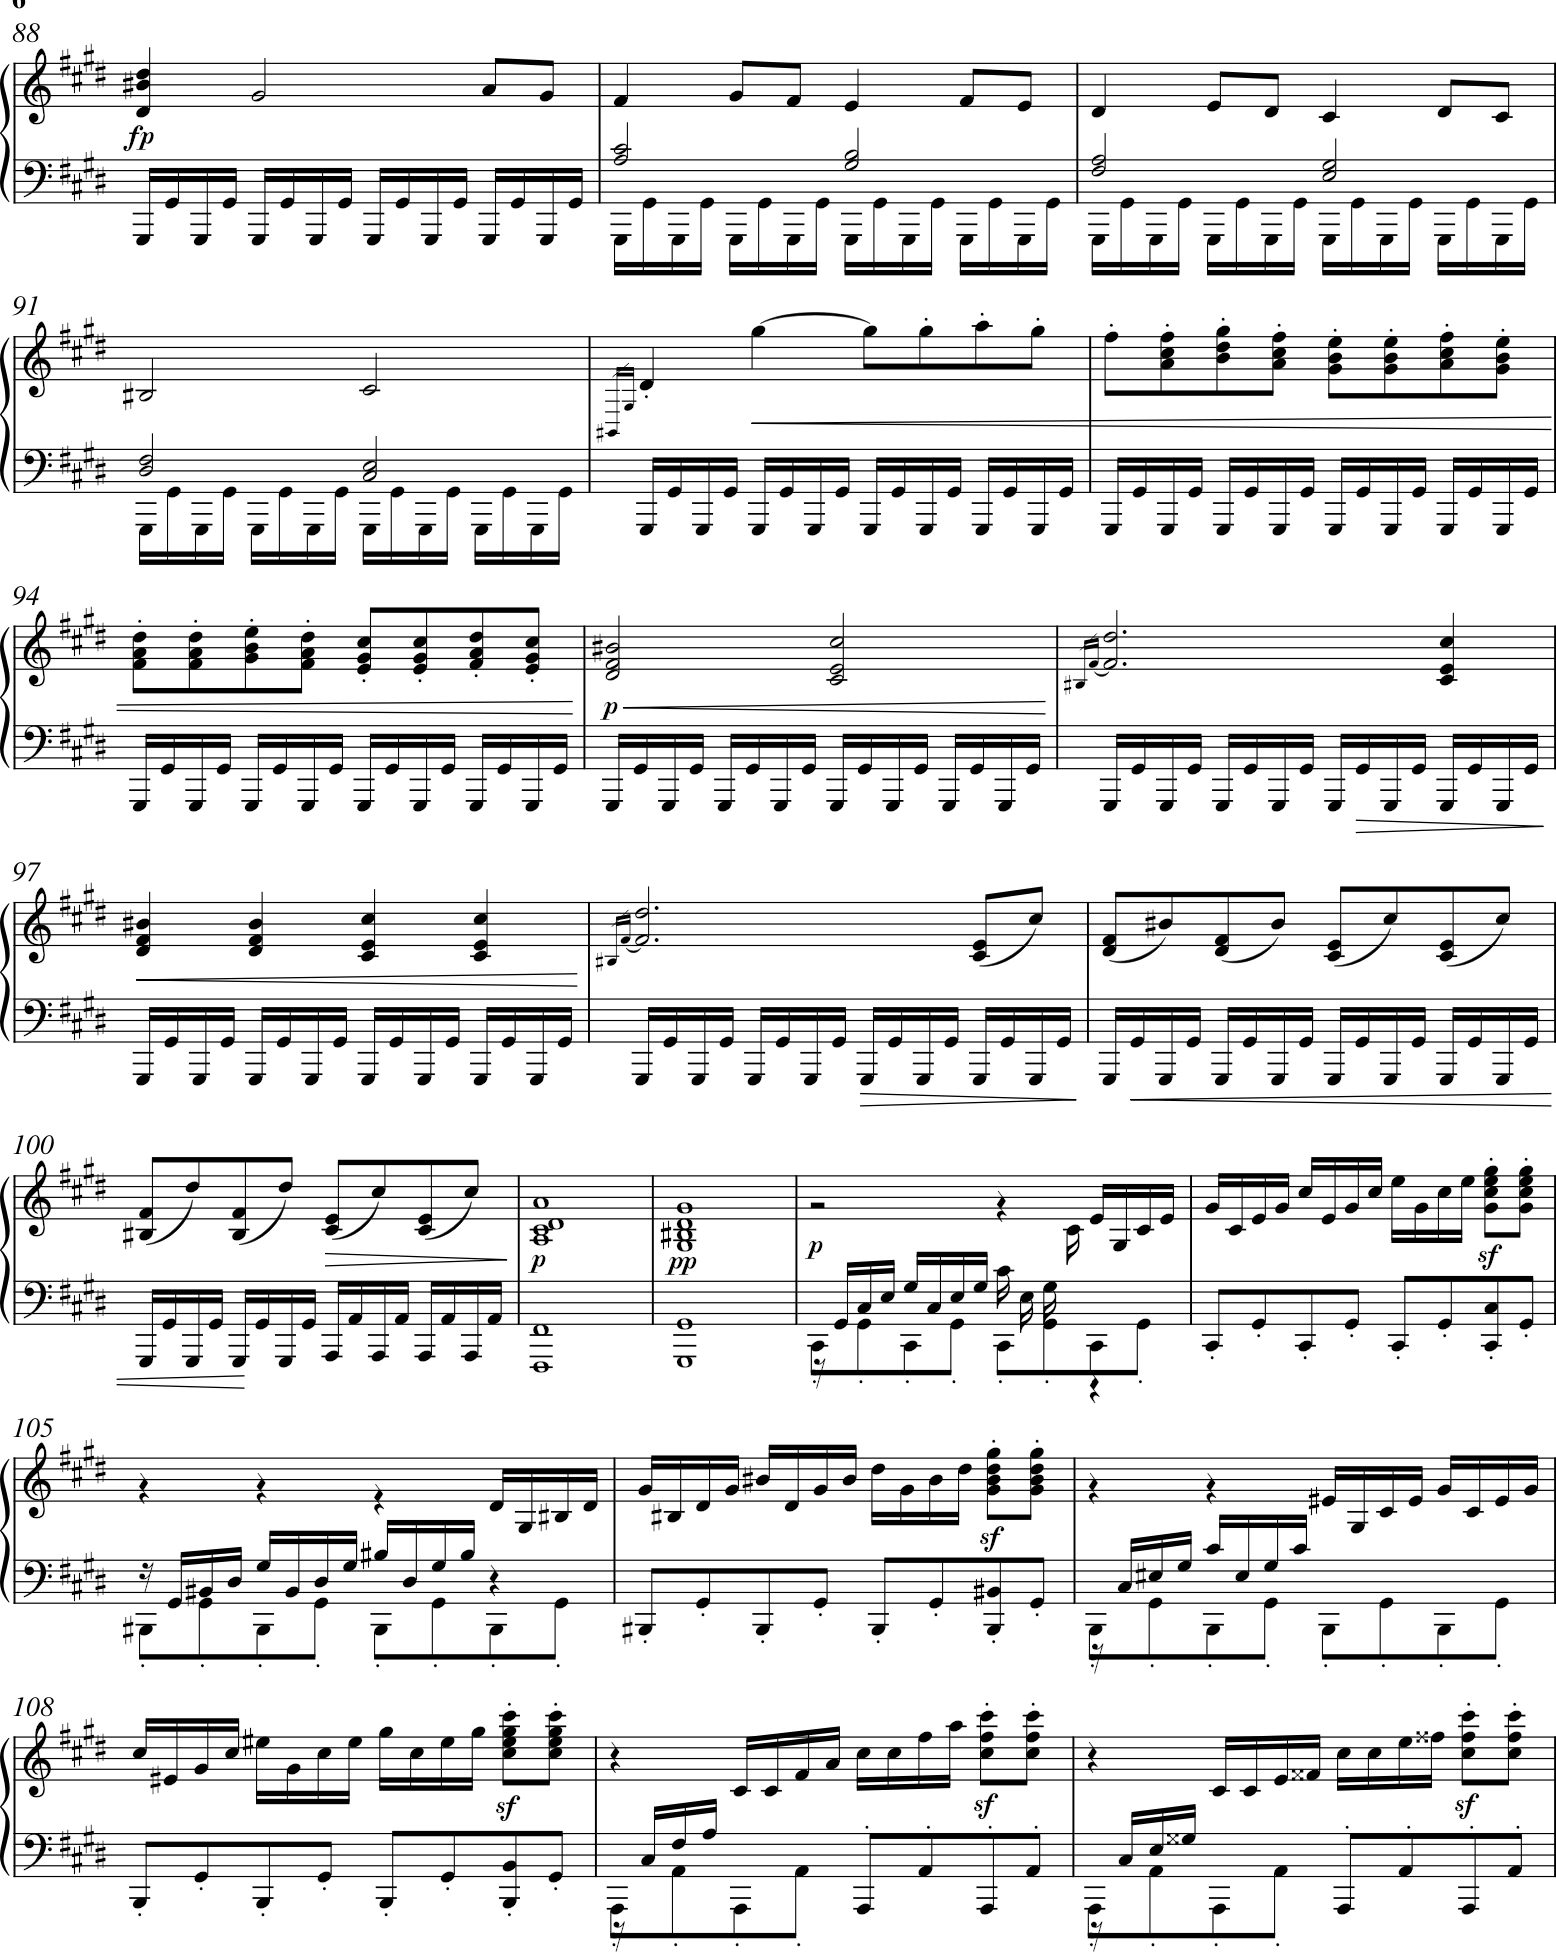

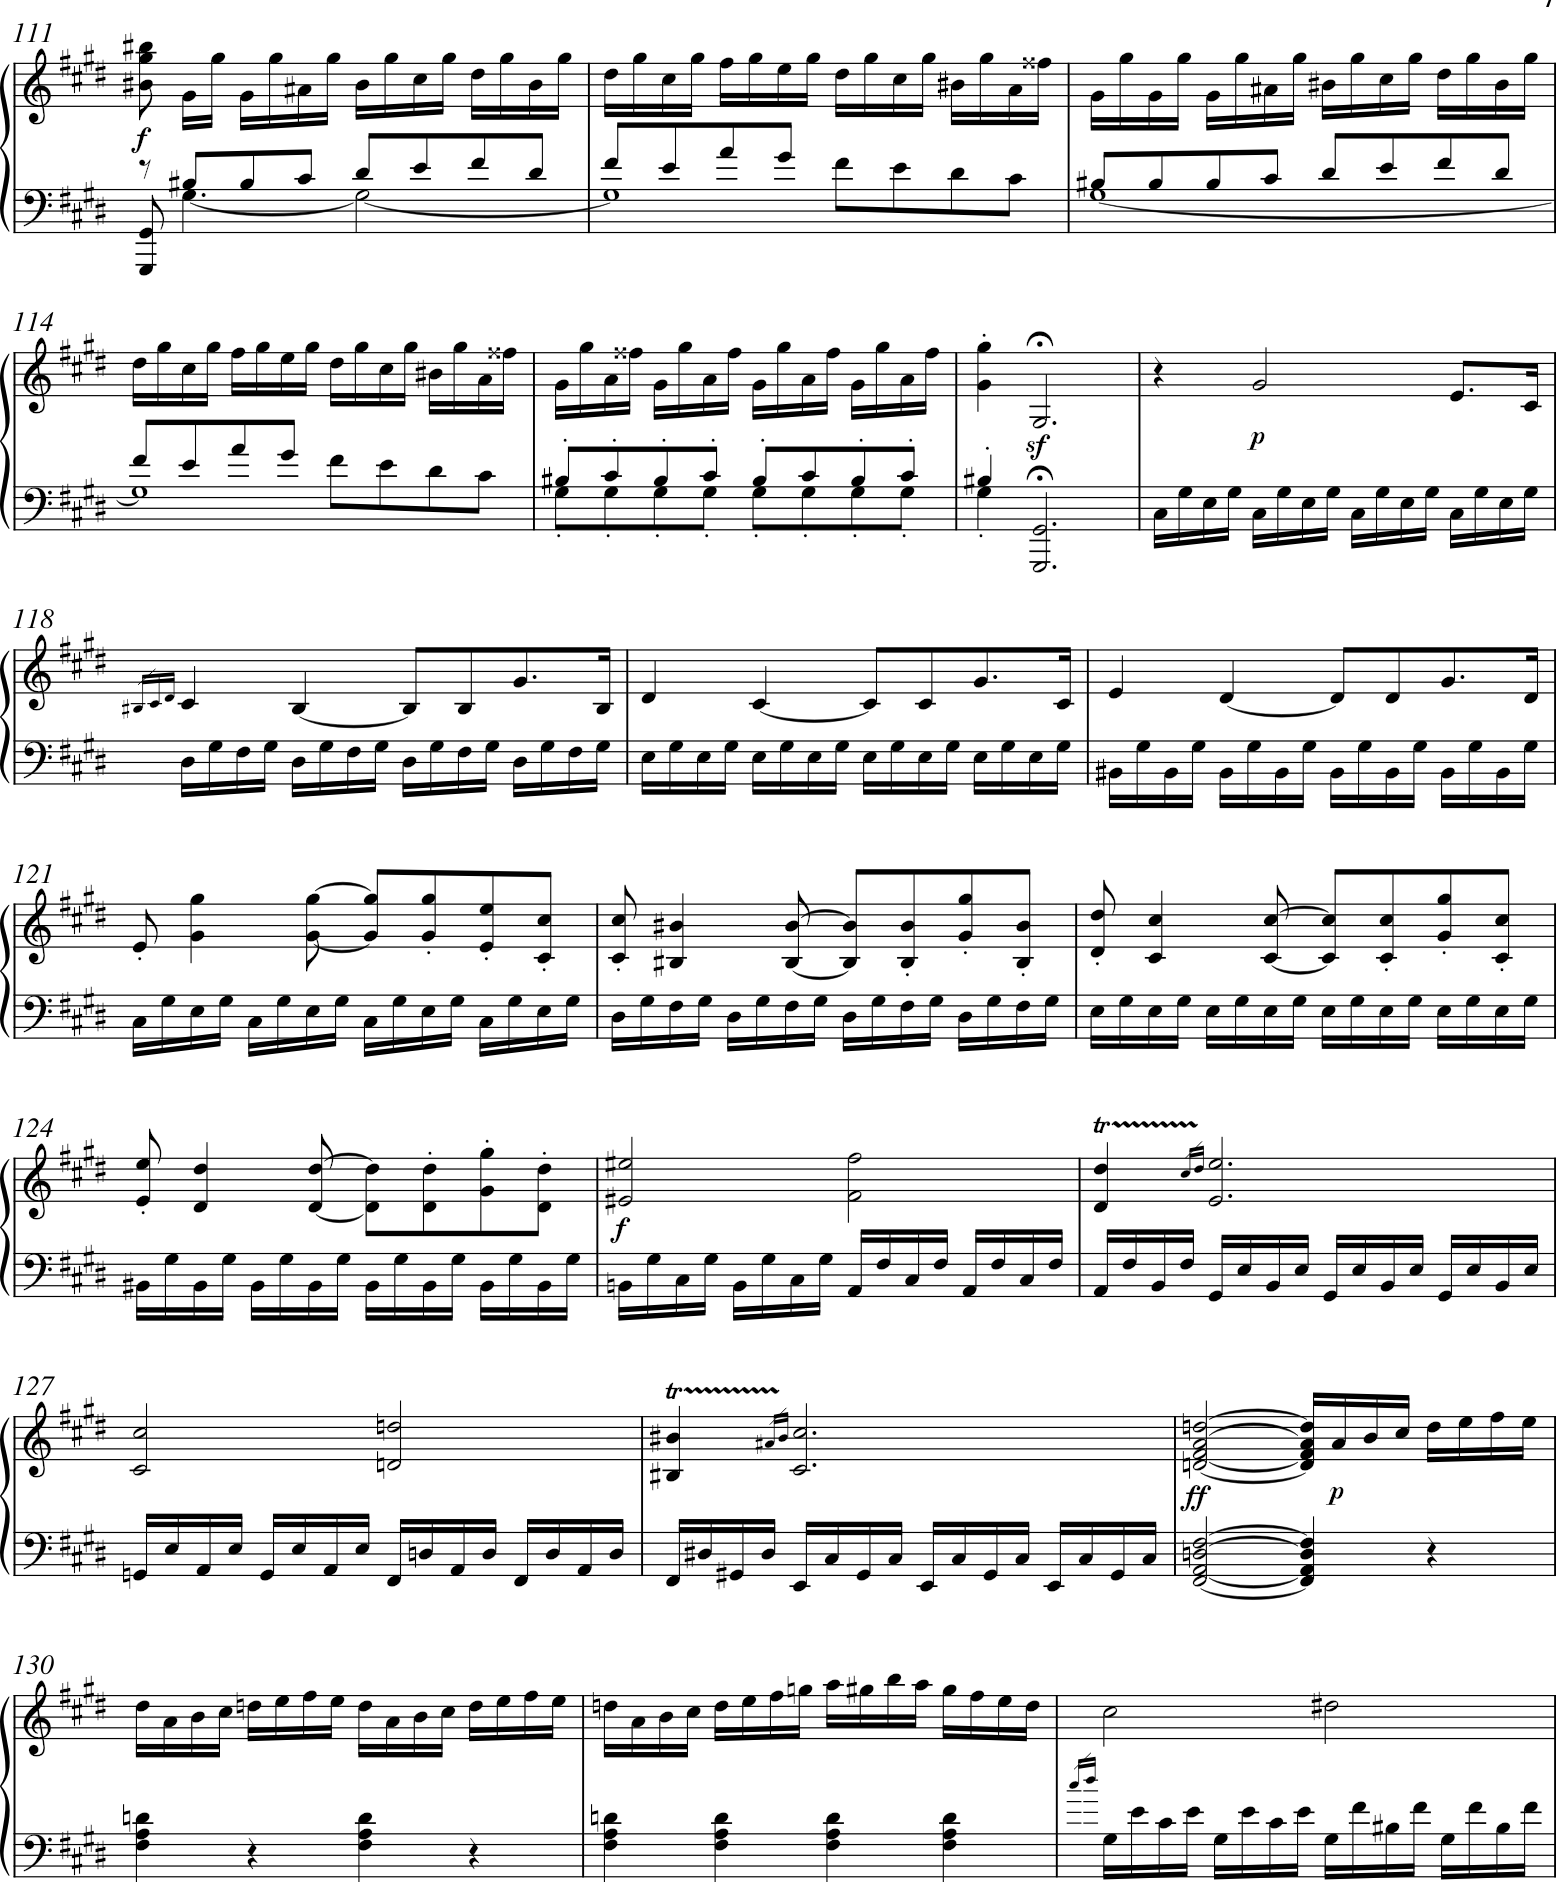

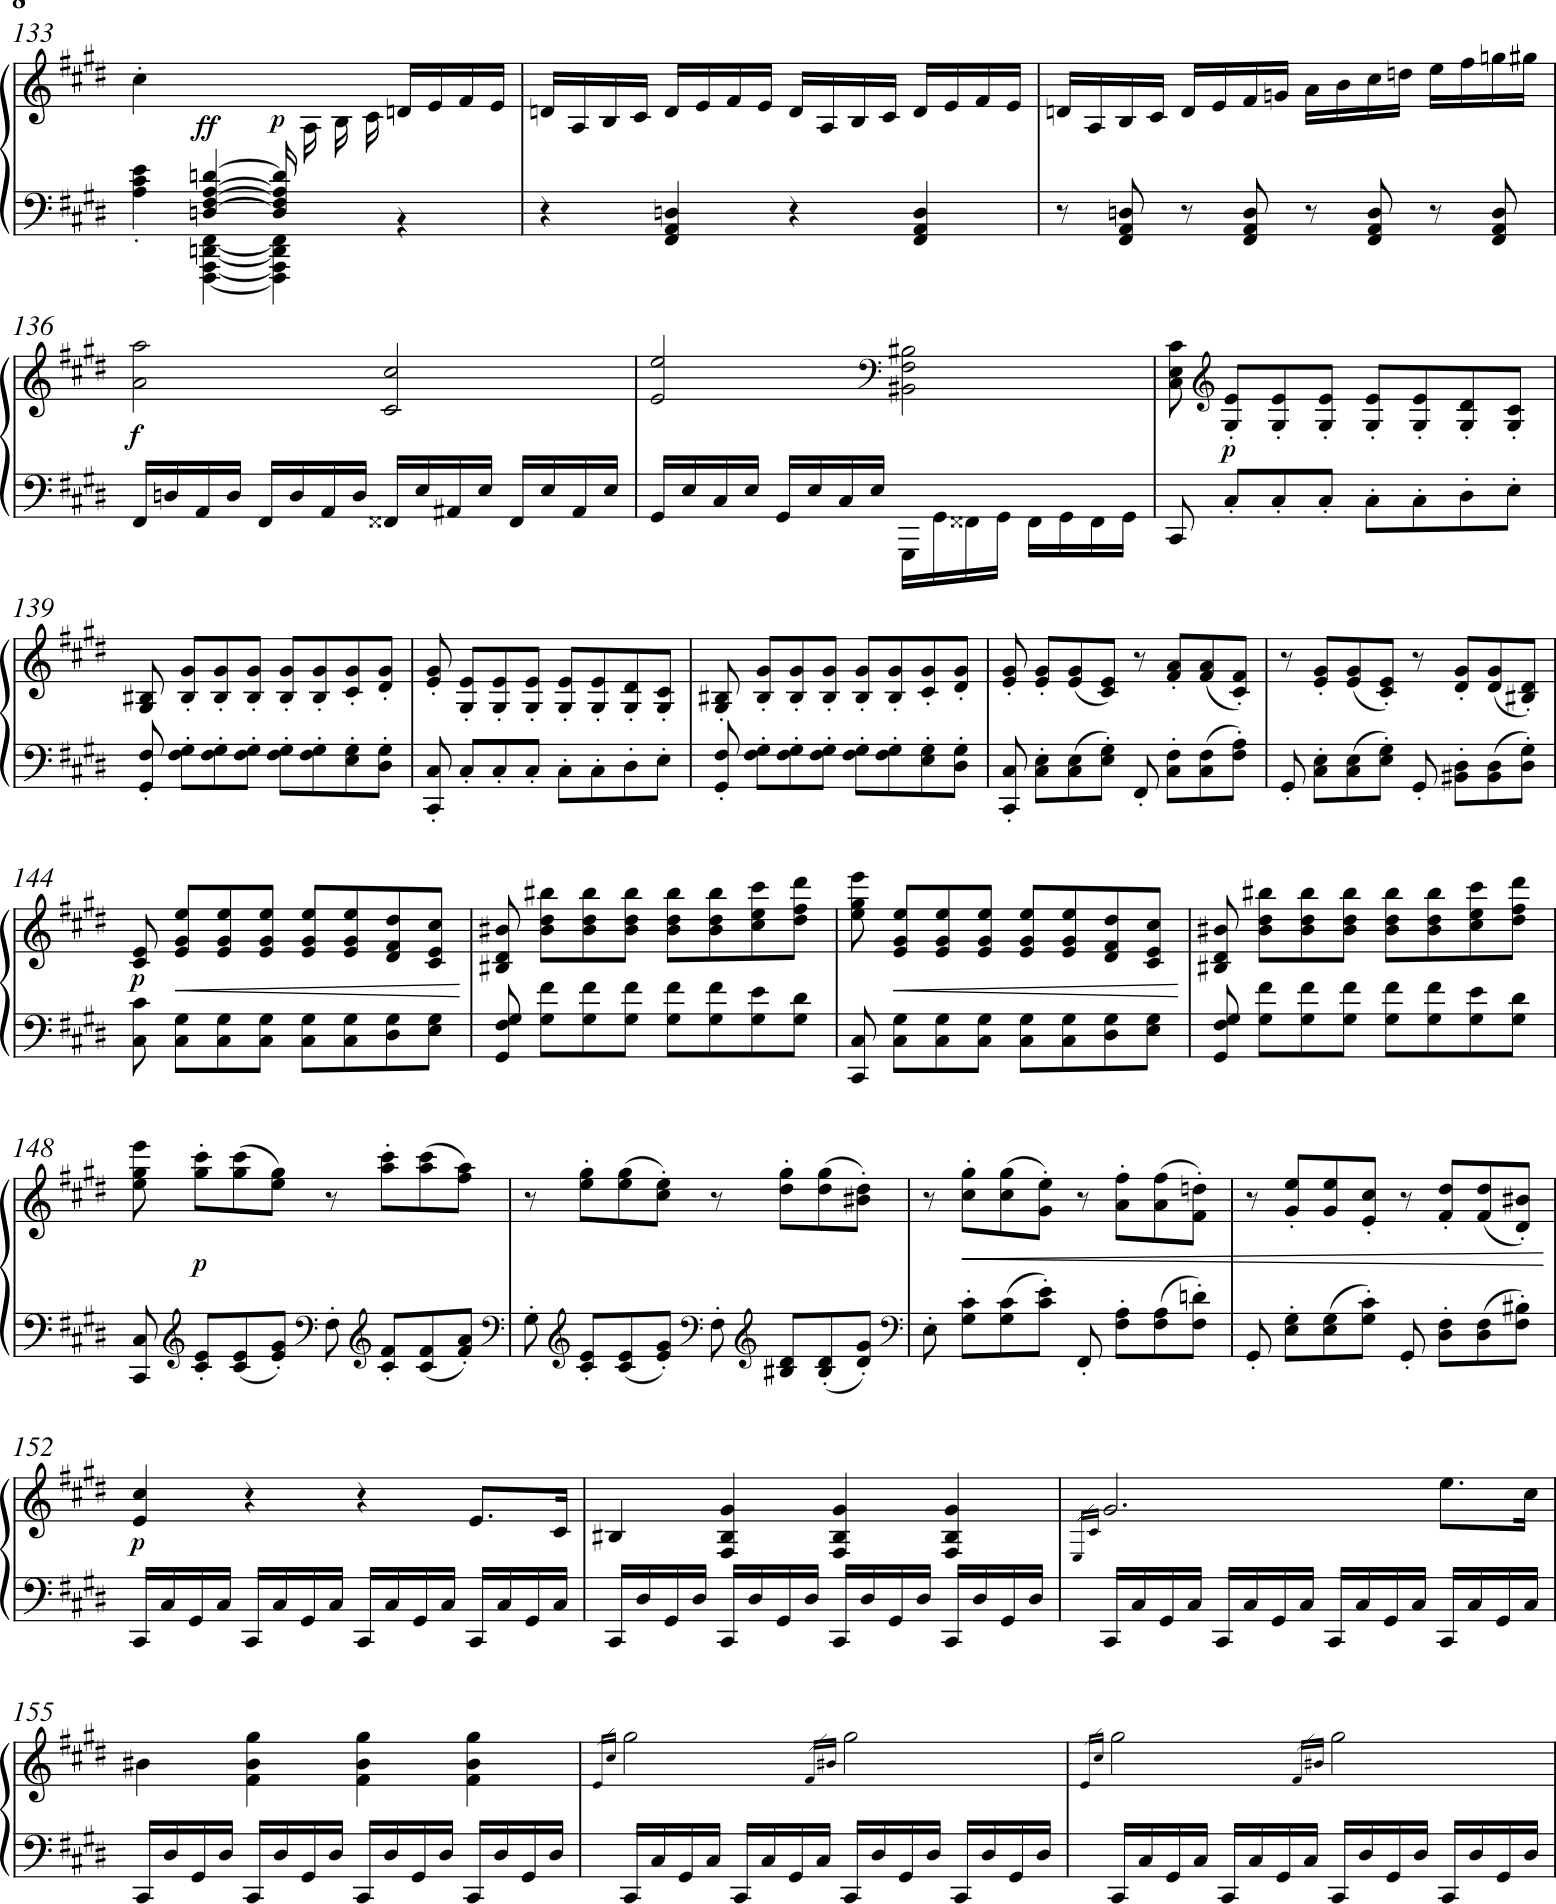

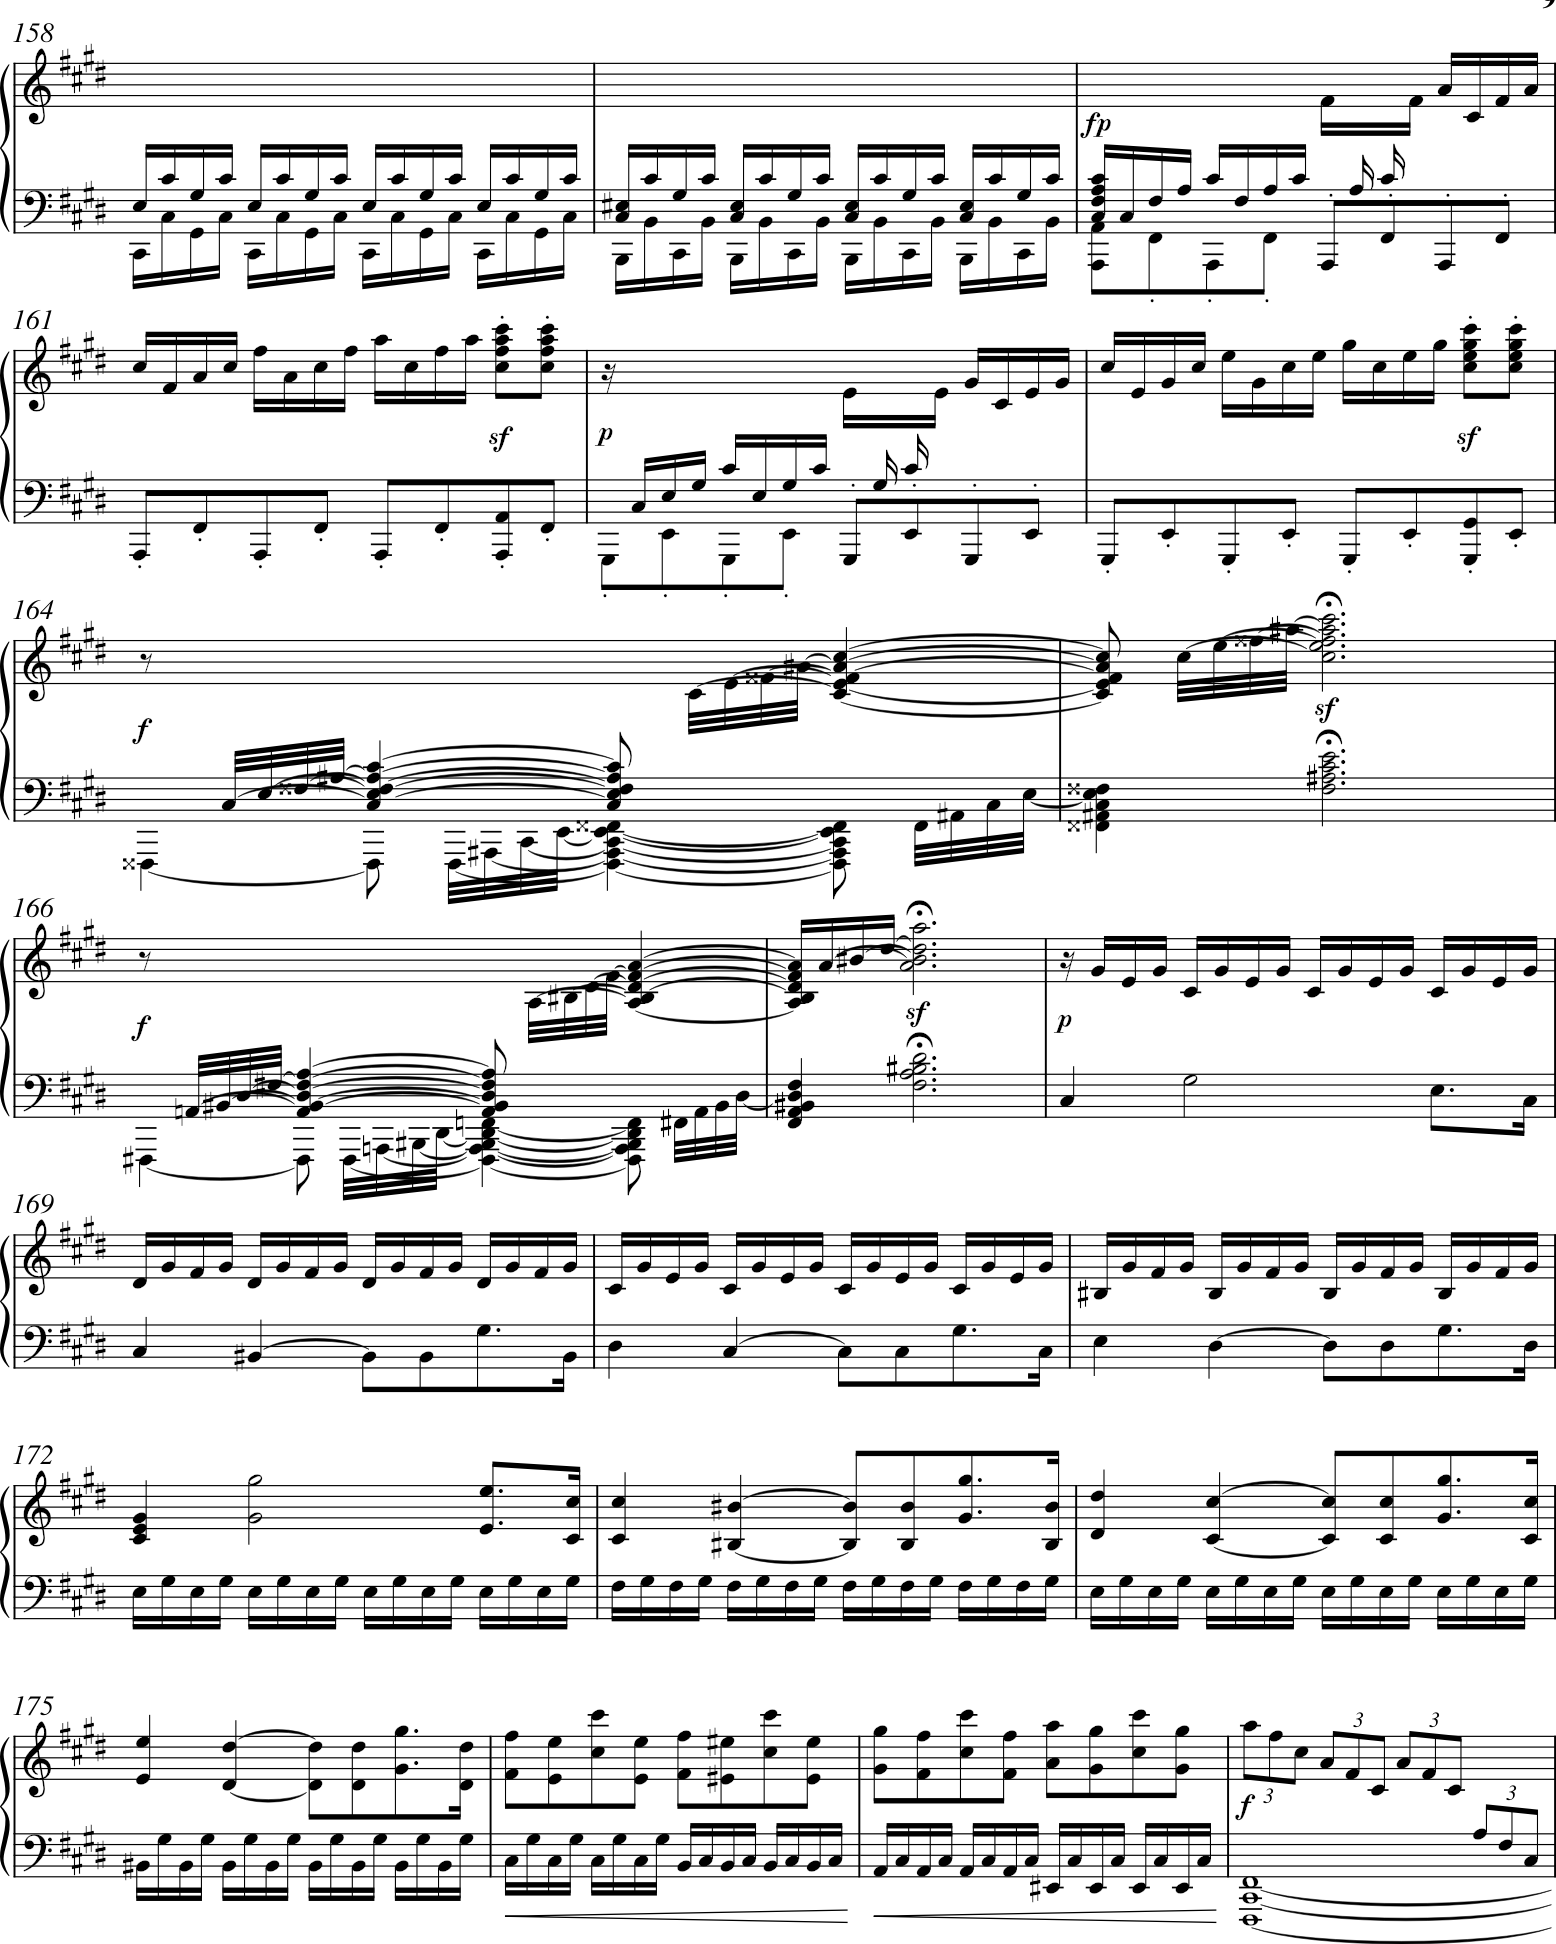

In [3]:
"""Cargar score"""

# score = converter.parse("data\Mozart_-_Lacrimosa_from_the_Requiem_in_D_minor.mxl")
# score = converter.parse("data\Mozart_K.488_Piano_Concerto_23_in_A_2nd_mov._Adagio_for_piano_solo.mxl")
score = converter.parse("data\moonlight_sonata_3rd_movement.mxl")
# score = converter.parse("data/humdrum-data/humdrum-data/beethoven/piano/sonata/beethoven-sonata01-1.krn")
score.show()

In [6]:
"""CODIDO ALFREDO"""
# matriz = process_notes(score)
matriz = np.load('data/beethoven-sonata01-1.npy',allow_pickle=True)

In [20]:
len(matriz)

1695

In [22]:
matriz[:30,:]

array([[0.0, 1.0, 1.0, 60, 0],
       [0.0, 1.0, 1.0, 65, 1],
       [1.0, 2.0, 1.0, 68, 1],
       [2.0, 3.0, 1.0, 72, 1],
       [3.0, 4.0, 1.0, 77, 1],
       [0.0, 1.5, 1.5, 80, 2],
       [1.5, 1.6666666666666667, Fraction(1, 6), 79, 2],
       [Fraction(5, 3), Fraction(11, 6), Fraction(1, 6), 77, 2],
       [Fraction(11, 6), Fraction(2, 1), Fraction(1, 6), 76, 2],
       [2.0, 3.0, 1.0, 77, 2],
       [0.0, 1.0, 1.0, 67, 3],
       [1.0, 2.0, 1.0, 72, 3],
       [2.0, 3.0, 1.0, 76, 3],
       [3.0, 4.0, 1.0, 79, 3],
       [0.0, 1.5, 1.5, 82, 4],
       [1.5, 1.6666666666666667, Fraction(1, 6), 80, 4],
       [Fraction(5, 3), Fraction(11, 6), Fraction(1, 6), 79, 4],
       [Fraction(11, 6), Fraction(2, 1), Fraction(1, 6), 77, 4],
       [2.0, 3.0, 1.0, 79, 4],
       [0.0, 0.0, 0.0, 72, 5],
       [0.0, 1.5, 1.5, 80, 5],
       [1.5, 1.6666666666666667, Fraction(1, 6), 79, 5],
       [Fraction(5, 3), Fraction(11, 6), Fraction(1, 6), 77, 5],
       [Fraction(11, 6), Fraction(2, 1)

In [23]:
matriz[1:,0] = matriz[1:,0] + (matriz[1:,4]-1)*4

In [25]:
matriz[:30,:]

array([[0.0, 1.0, 1.0, 60, 0],
       [0.0, 1.0, 1.0, 65, 1],
       [1.0, 2.0, 1.0, 68, 1],
       [2.0, 3.0, 1.0, 72, 1],
       [3.0, 4.0, 1.0, 77, 1],
       [4.0, 1.5, 1.5, 80, 2],
       [5.5, 1.6666666666666667, Fraction(1, 6), 79, 2],
       [Fraction(17, 3), Fraction(11, 6), Fraction(1, 6), 77, 2],
       [Fraction(35, 6), Fraction(2, 1), Fraction(1, 6), 76, 2],
       [6.0, 3.0, 1.0, 77, 2],
       [8.0, 1.0, 1.0, 67, 3],
       [9.0, 2.0, 1.0, 72, 3],
       [10.0, 3.0, 1.0, 76, 3],
       [11.0, 4.0, 1.0, 79, 3],
       [12.0, 1.5, 1.5, 82, 4],
       [13.5, 1.6666666666666667, Fraction(1, 6), 80, 4],
       [Fraction(41, 3), Fraction(11, 6), Fraction(1, 6), 79, 4],
       [Fraction(83, 6), Fraction(2, 1), Fraction(1, 6), 77, 4],
       [14.0, 3.0, 1.0, 79, 4],
       [16.0, 0.0, 0.0, 72, 5],
       [16.0, 1.5, 1.5, 80, 5],
       [17.5, 1.6666666666666667, Fraction(1, 6), 79, 5],
       [Fraction(53, 3), Fraction(11, 6), Fraction(1, 6), 77, 5],
       [Fraction(107, 6), Fr

In [17]:
midi_to_note(76)

'E5'

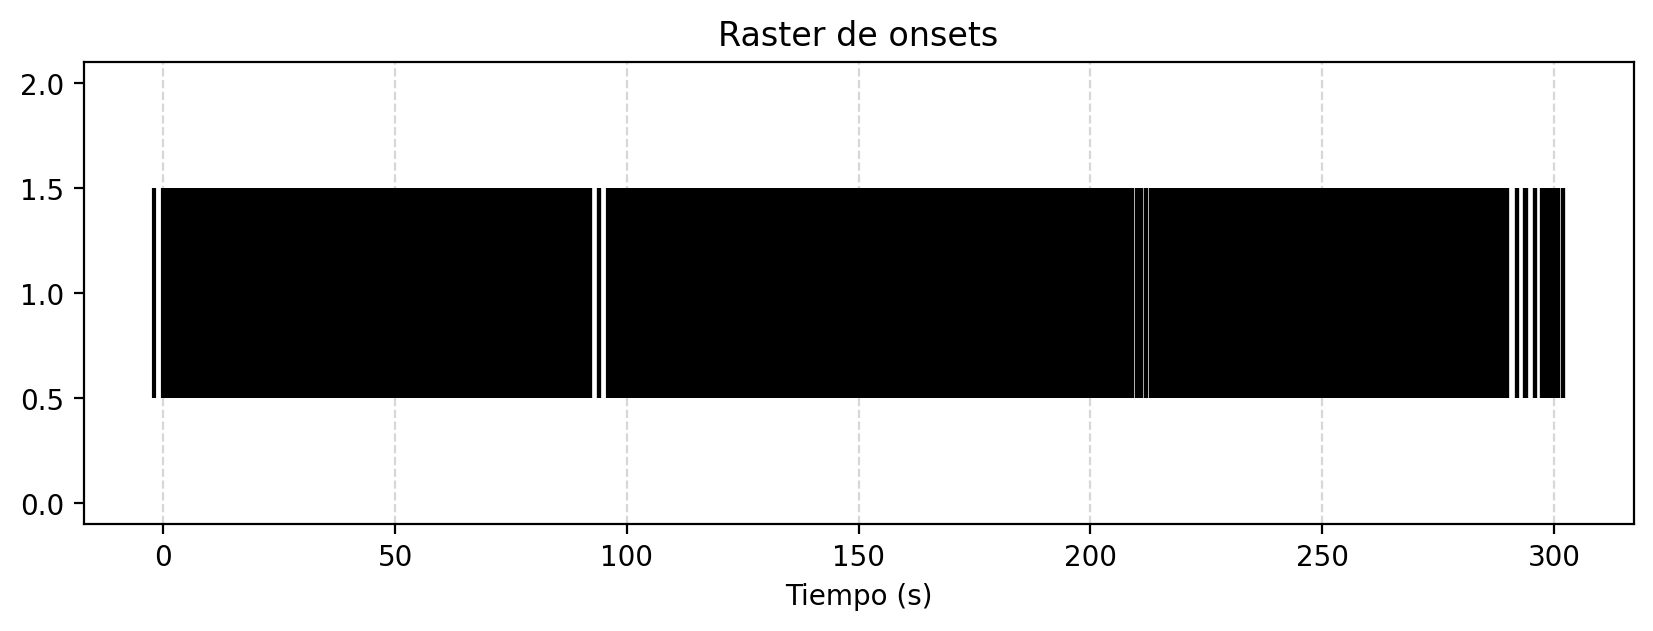

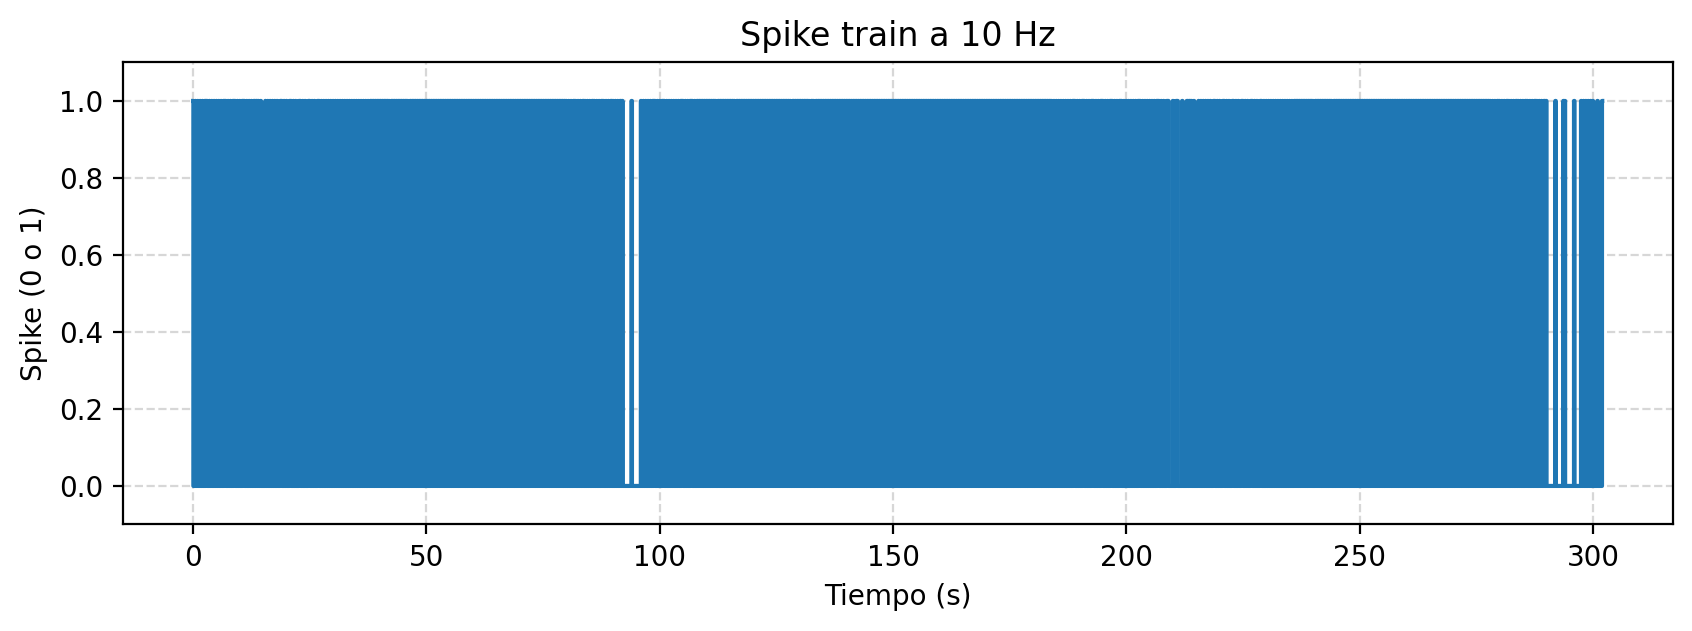

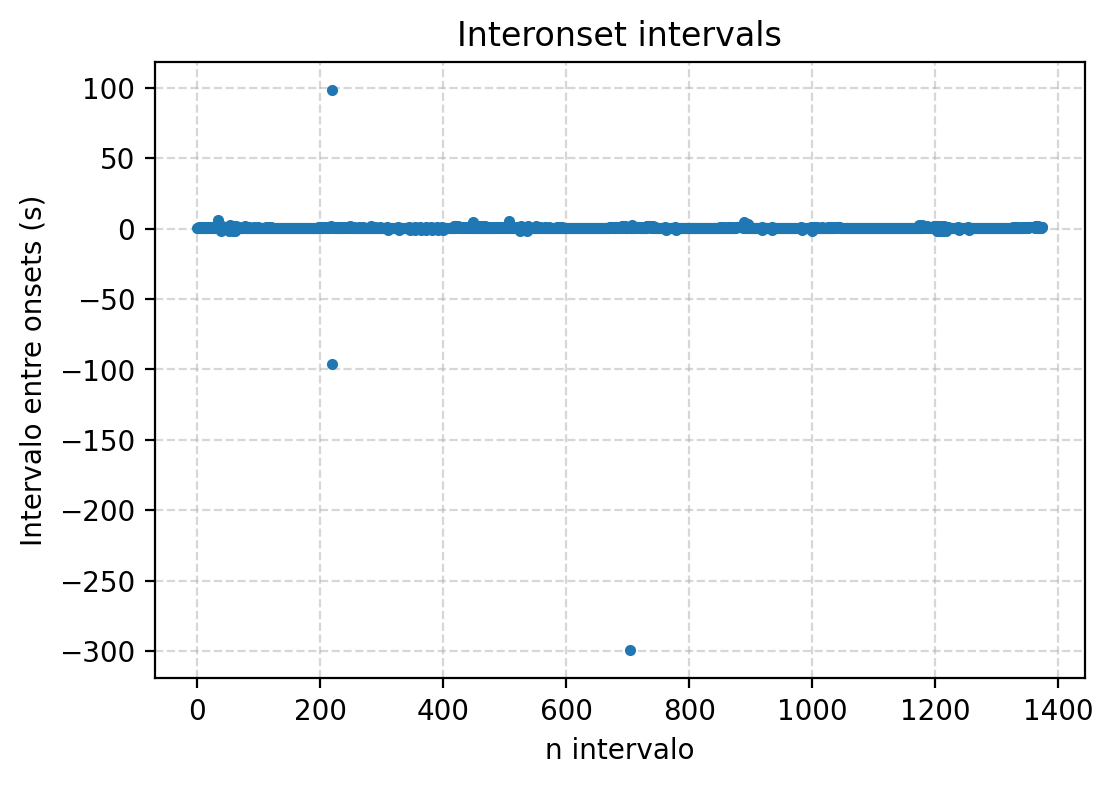

In [26]:
import numpy as np

# Ejemplo: tu matriz cargada
# matriz = np.loadtxt('mi_matriz.csv', delimiter=',')

# Tempo en negras por minuto (definido por ti)
N = 120  # ejemplo: 90 bpm

# Tiempo de una negra en segundos
T_negra = 60 / N

# Extraer onsets y convertir a segundos
onsets_negras = remove_consecutive_duplicates(matriz[:,0]) #### CUIDADO 
onsets_segundos = onsets_negras * T_negra

# Ordenar por onset si no están ordenados
# onsets_segundos = np.sort(onsets_segundos)

# Calcular interonset intervals
interonset_intervals = np.diff(onsets_segundos)

if False:
    interonset_intervals = np.random.permutation(interonset_intervals)
    onsets_segundos = np.concatenate([[onsets_segundos[0]], onsets_segundos[0] + np.cumsum(interonset_intervals)])


# Crear spike train a 10 Hz (10 muestras por segundo)
fs = 10  # frecuencia de muestreo (Hz)
dt = 1 / fs

# Eje temporal
t_max = np.max(onsets_segundos) + dt
t_axis = np.arange(0, t_max, dt)

# Inicializar spike train
spike_train = np.zeros_like(t_axis)

# Marcar spikes en el bin más cercano
for onset in onsets_segundos:
    idx = np.argmin(np.abs(t_axis - onset))
    spike_train[idx] = 1

# --- Raster: spikes sobre eje temporal ---
plt.figure(figsize=(10, 3))
plt.eventplot(onsets_segundos, orientation='horizontal', colors='black')
plt.xlabel('Tiempo (s)')
plt.title('Raster de onsets')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()

# --- Spike train como señal binaria ---
plt.figure(figsize=(10, 3))
plt.step(t_axis, spike_train, where='mid')
plt.xlabel('Tiempo (s)')
plt.ylabel('Spike (0 o 1)')
plt.title('Spike train a 10 Hz')
plt.ylim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- Histograma de interonset intervals ---
plt.figure(figsize=(6, 4))
plt.plot(interonset_intervals,'.')
plt.xlabel('n intervalo')
plt.ylabel('Intervalo entre onsets (s)')
plt.title('Interonset intervals')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



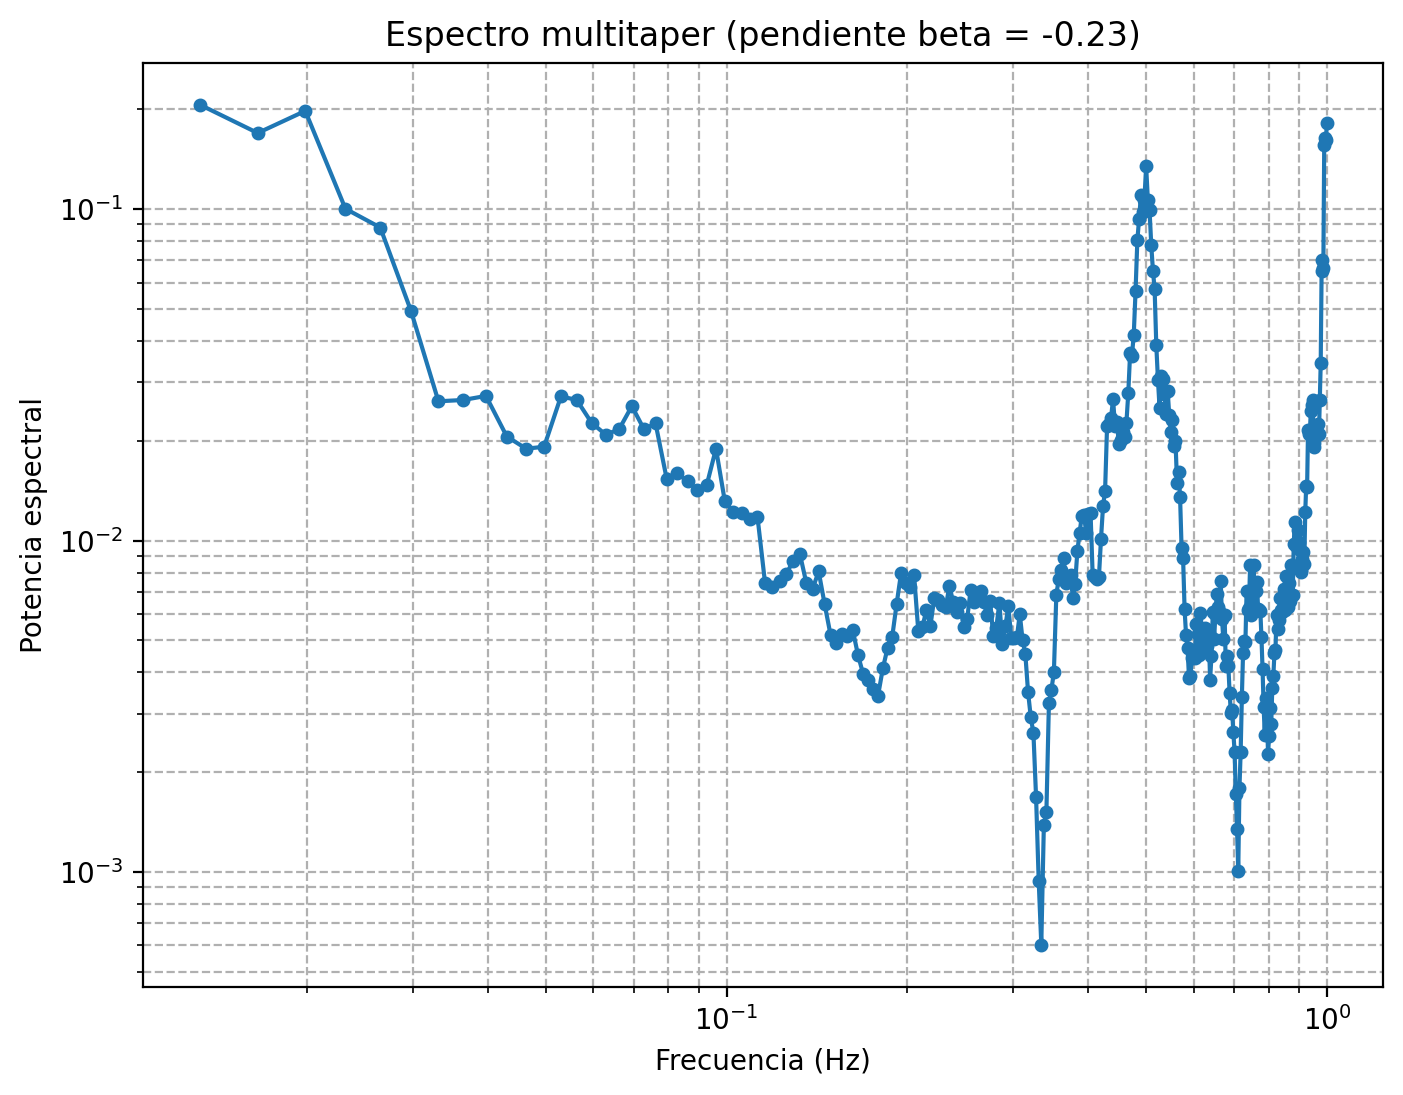

In [27]:
import matplotlib.pyplot as plt
from mne.time_frequency import psd_array_multitaper

# Calcular el espectro multitaper
psd, freqs = psd_array_multitaper(
    spike_train, sfreq=fs, fmin=0.01, fmax=1, adaptive=True, normalization='full', verbose=False
)

# Pasar a escala log-log
log_freqs = np.log10(freqs)
log_psd = np.log10(psd)

# Ajuste lineal (regresión robusta opcional: aquí usaremos numpy.polyfit para ejemplo)
mask = (freqs >= 0.01) & (freqs <= 1)
slope, intercept = np.polyfit(log_freqs[mask], log_psd[mask], 1)

# Graficar
plt.figure(figsize=(8,6))
plt.plot(freqs, psd, 'o-', markersize=4)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Potencia espectral')
plt.title(f'Espectro multitaper (pendiente beta = {slope:.2f})')
plt.grid(True, which="both", ls="--")
plt.show()


In [51]:
print(J_univariante(interpolador(generar_uniforme_centrada(10000,1e-5),'lineal',10)[1]))

0.8897919029200937


10462
0.9352050313702769


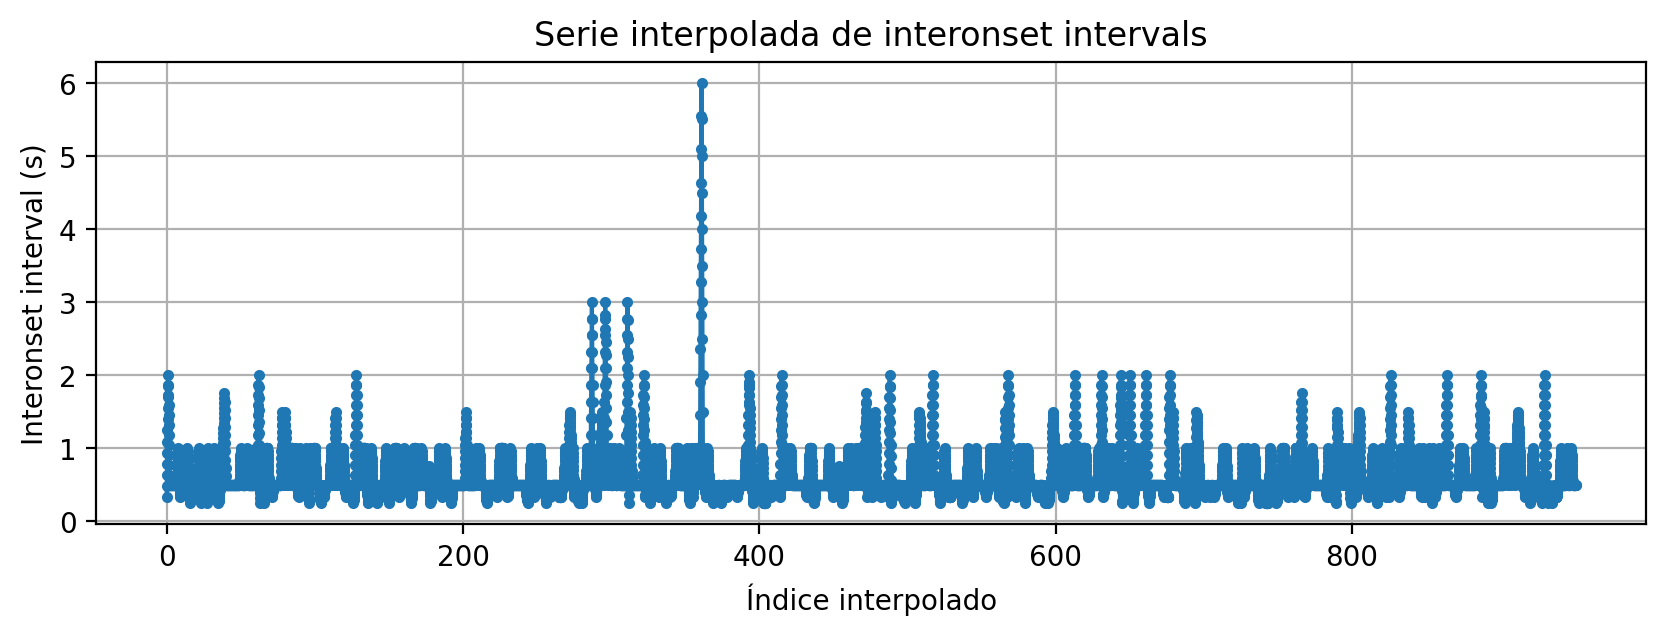

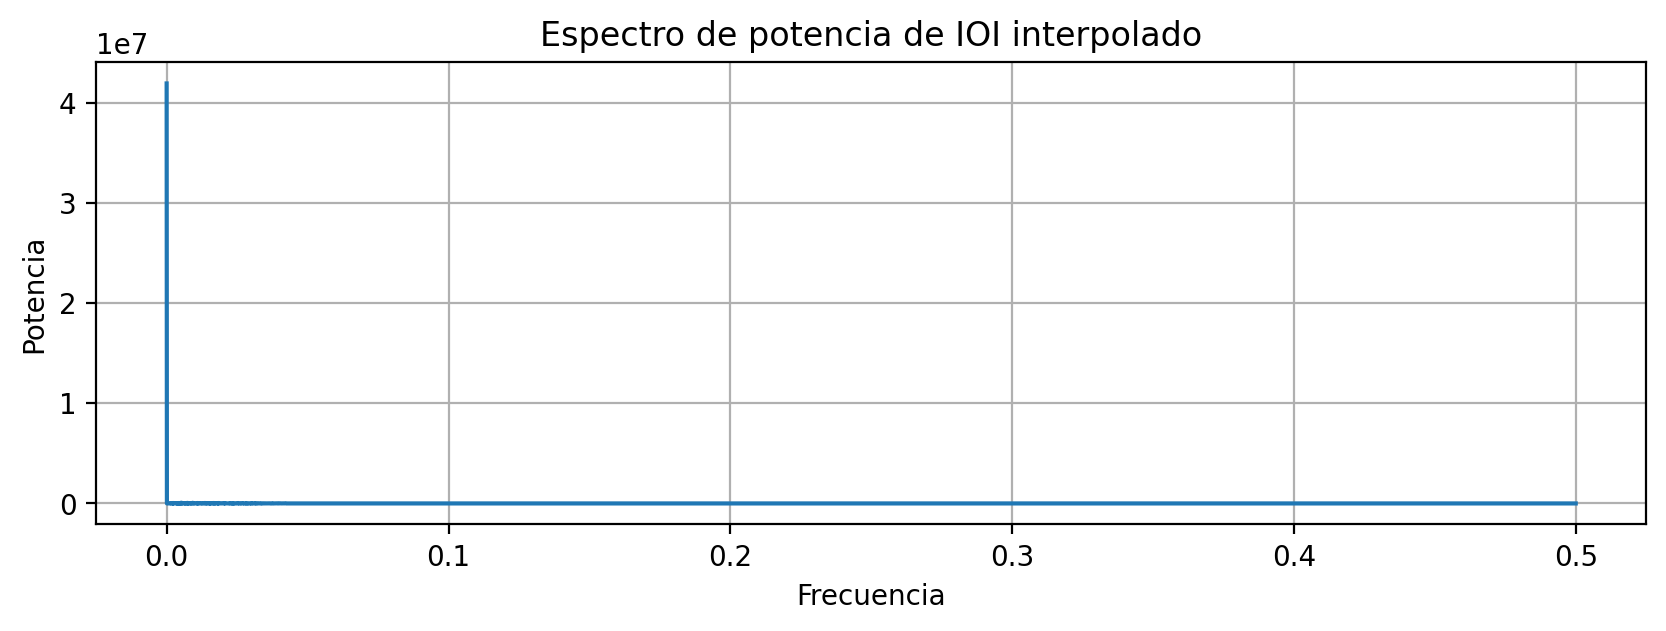

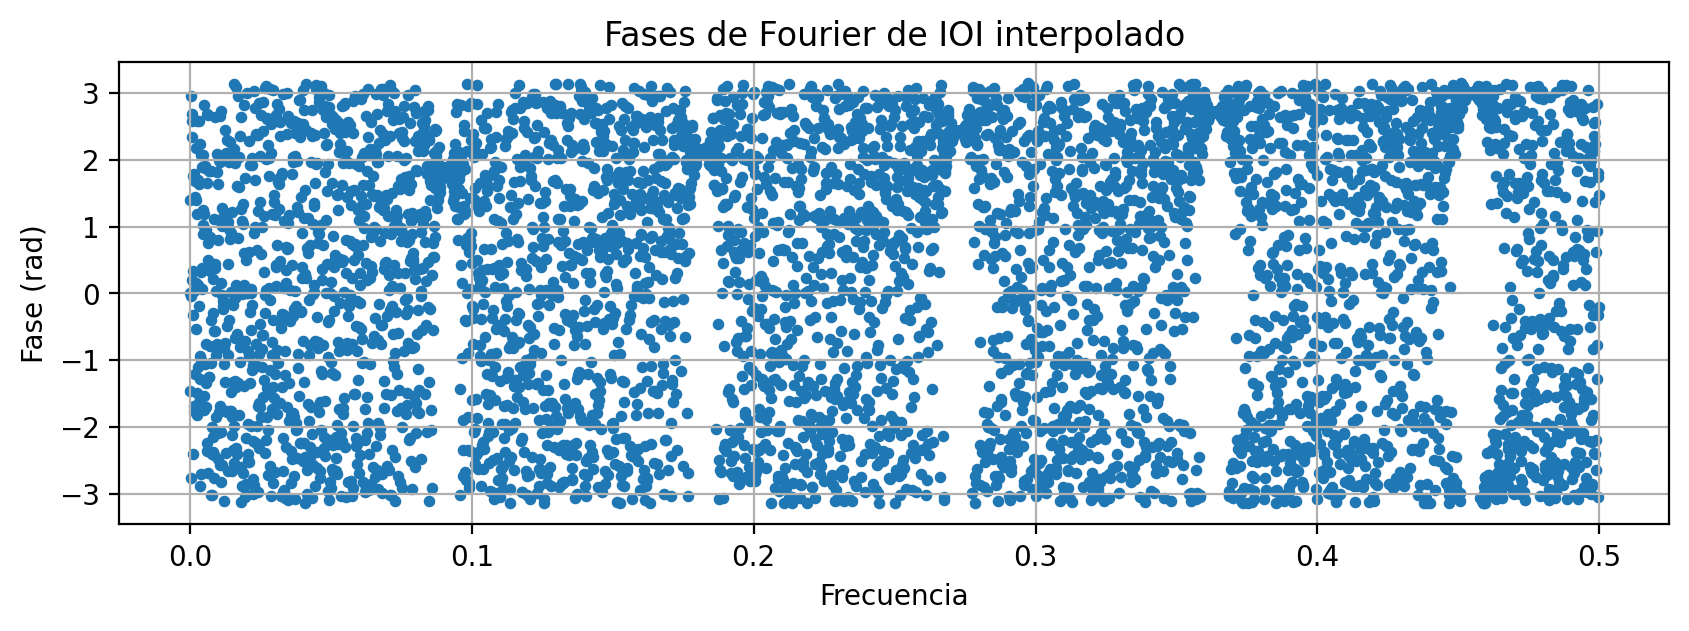

In [78]:
from scipy.interpolate import PchipInterpolator
from scipy.fft import fft


x_new, ioi_interp = interpolador(interonset_intervals, method='lineal', size=10)
print(len(ioi_interp))
# === FFT ===
fft_result = fft(ioi_interp)
power = np.abs(fft_result)**2
phase = np.angle(fft_result)

# === Frecuencias asociadas ===
fs = 1  # Como estamos trabajando en índice de IOIs (no en tiempo real), fs=1
freqs = np.fft.fftfreq(len(ioi_interp), d=1/fs)

# === Gráficas ===

# Serie interpolada
plt.figure(figsize=(10, 3))
plt.plot(x_new, ioi_interp,'.-')
plt.title('Serie interpolada de interonset intervals')
plt.xlabel('Índice interpolado')
plt.ylabel('Interonset interval (s)')
plt.grid(True)

# Espectro de potencia
plt.figure(figsize=(10, 3))
plt.plot(freqs[:len(freqs)//2], power[:len(freqs)//2])
plt.title('Espectro de potencia de IOI interpolado')
plt.xlabel('Frecuencia')
plt.ylabel('Potencia')
plt.grid(True)

# Fases de Fourier
print(J_univariante(ioi_interp))
plt.figure(figsize=(10, 3))
plt.scatter(freqs[:len(freqs)//2], phase[:len(freqs)//2], s=10)
plt.title('Fases de Fourier de IOI interpolado')
plt.xlabel('Frecuencia')
plt.ylabel('Fase (rad)')
plt.grid(True)

plt.show()
